# --- PART 1: Data Exploration and Data Understanding---

In [60]:
heart_df = pd.read_csv('../Data/heart_diagnoses_1.csv')
laboratory_df = pd.read_csv('../Data/laboratory_events_codes_2.csv')
microbiology_df = pd.read_csv('../Data/microbiology_events_codes_3.csv')
procedures_df = pd.read_csv('../Data/procedure_code_4.csv')
heart_df.head()


heart_df.head(100).to_csv('../Data/heart_head.csv', index=False)
laboratory_df.head(100).to_csv('../Data/laboratory_head.csv', index=False)
microbiology_df.head(100).to_csv('../Data/microbiology_head.csv', index=False)
procedures_df.head(100).to_csv('../Data/procedures_head.csv', index=False)

In [61]:
top_subjects = heart_df.groupby(["subject_id"]).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
heart_df[heart_df['subject_id'] == 11296936]

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,ECG,MRI,reports,subject_id_dx,icd_code,long_title,gender,age,anchor_year,dod
586,11296936-DS-58,11296936,25785943,DS,58,2145-06-28 03:00:00,2145-06-28 20:03:00,:\nMr. ___ is a ___ year old gentleman with a ...,T: 96.3 BP: 144/94 HR: 107 RR: 18 O2 96% RA\nG...,\nchest pain\n \n,...,['___: atrial tach with 2:1 conduction at ~108...,[],Sinus rhythm | Possible right atrial abnormali...,11296936,I50,Heart failure,NaN,NaN,NaN,NaN
587,11296936-DS-71,11296936,27433694,DS,71,2146-09-22 03:00:00,2146-09-23 10:36:00,":\n___ yo man with h/o ESRD on HD and anuric, ...",Physical exam on admission:VS - Temp: 98.4 BP:...,\nCHEST PAIN\n \n,...,[],[],Sinus rhythm | Possible right atrial abnormali...,11296936,I50,Heart failure,NaN,NaN,NaN,NaN
588,11296936-DS-88,11296936,25125890,DS,88,2148-02-11 03:00:00,2148-02-11 16:38:00,:\nMr. ___ is a ___ M with ESRD on HD (last HD...,Admission Physical Exam:\nVitals: T: 97.8 BP:1...,"\nnausea, vomiting \n\n \n",...,[':\n___: Probable atrial flutter with 2:1 A-...,[],Sinus rhythm | Possible right atrial abnormali...,11296936,I48,Atrial fibrillation and flutter,NaN,NaN,NaN,NaN
589,11296936-DS-92,11296936,26187064,DS,92,2148-09-24 03:00:00,2148-09-26 18:32:00,":\nThis is a ___ M PMHx HTN, ESRD on HD, CHF (...",Vitals: 99.0 92 134/72 22 90%6LNC\nADMISSION E...,\nShortness of Breath\n \n,...,['___\nAtrial flutter with a rapid ventricular...,[],Sinus rhythm | Possible right atrial abnormali...,11296936,I50,Heart failure,NaN,NaN,NaN,NaN
590,11296936-DS-94,11296936,26914486,DS,94,2148-12-04 03:00:00,2148-12-05 19:57:00,:\n___ with history of T2DM complicated by ESR...,PHYSICAL EXAM ON ADMISSION: \nVS - 97.5 167/...,\nchest pain \n \n,...,"[': afib at ~100, PRWP, nonspecific ST-T chang...",[],Sinus rhythm | Possible right atrial abnormali...,11296936,I50,Heart failure,NaN,NaN,NaN,NaN


In [62]:
top_subjects

,subject_id,counts
1460,13398773,5
531,11296936,5
3372,17890530,5
721,11760589,4
1041,12426774,4
...,...,...
4387,19998596,1
4388,19998597,1
4389,19998598,1
4390,19998599,1


In [63]:
def trackMissingValues(df):
    null_df = df.isnull().sum().to_frame(name="null_count")
    null_df["ratio"] = null_df["null_count"] / len(df)*100
    return null_df

trackMissingValues(microbiology_df)

,null_count,ratio
subject_id,0,0.000000
hadm_id,0,0.000000
chartdate,0,0.000000
charttime,0,0.000000
spec_type_desc,0,0.000000
test_name,0,0.000000
org_name,10196,65.413486
ab_name,10767,69.076795
dilution_text,10874,69.763264
dilution_comparison,10876,69.776095


In [64]:
len(procedures_df)

14497

In [65]:
laboratory_df[laboratory_df["valuenum"].notnull()& laboratory_df["valueuom"].isnull()]
laboratory_df[laboratory_df["ref_range_lower"].isnull() & laboratory_df["flag"].notnull()]


,hadm_id,charttime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,label,fluid,examination_group,analysis_batch_id,qc_flag,ref_range
3233,29728342.0,2115-06-08 04:00:00,NaN,NaN,NaN,NaN,NaN,abnormal,Platelet Smear,Blood,Blood Cell Morphology,BATCH_211506_S9,WARN,Normal range: 10-20
3248,29728342.0,2115-06-08 11:04:00,NaN,NaN,/hpf,NaN,NaN,abnormal,Bacteria,Urine,Urine Test,BATCH_211506_P5,OK,NaN
3250,29728342.0,2115-06-08 11:04:00,NaN,NaN,NaN,NaN,NaN,abnormal,Blood,Urine,Urine Test,BATCH_211506_G2,WARN,NaN
3255,29728342.0,2115-06-08 11:04:00,NaN,NaN,NaN,NaN,NaN,abnormal,Leukocytes,Urine,Urine Test,BATCH_211506_O8,WARN,Normal range: 70-110
3261,29728342.0,2115-06-08 11:04:00,NaN,NaN,NaN,NaN,NaN,abnormal,Urine Appearance,Urine,Urine Test,BATCH_211506_Y3,OK,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973572,28592225.0,2153-04-24 02:25:00,NaN,NaN,NaN,NaN,NaN,abnormal,Leukocytes,Urine,Urine Test,BATCH_215304_X2,OK,NaN
973578,28592225.0,2153-04-24 02:25:00,NaN,NaN,NaN,NaN,NaN,abnormal,Urine Appearance,Urine,Urine Test,BATCH_215304_S4,OK,NaN
973579,28592225.0,2153-04-24 02:25:00,NaN,NaN,NaN,NaN,NaN,abnormal,Urine Color,Urine,Urine Test,BATCH_215304_O9,OK,NaN
973582,28592225.0,2153-04-24 02:25:00,NaN,NaN,/hpf,NaN,NaN,abnormal,WBC Clumps,Urine,Urine Test,BATCH_215304_C6,OK,NaN


In [66]:
# Check duplicate counts 
print("Laboratory duplicates:")
print(laboratory_df.duplicated().value_counts())

print("\nMicrobiology duplicates:")
print(microbiology_df.duplicated().value_counts())


Laboratory duplicates:
False    978501
True          2
Name: count, dtype: int64

Microbiology duplicates:
False    15586
True         1
Name: count, dtype: int64


In [67]:
def drop_duplicates(df):
    """
    Remove duplicate rows and report the change in shape.
    """
    original_shape = df.shape
    df.drop_duplicates(inplace=True)
    new_shape = df.shape

    print(f"Original shape: {original_shape}")
    print(f"New shape: {new_shape}")

    return df


# Apply duplicate removal to datasets
for dataset in [heart_df, laboratory_df, microbiology_df, procedures_df]:
    drop_duplicates(dataset)

Original shape: (4864, 25)
New shape: (4864, 25)
Original shape: (978503, 14)
New shape: (978501, 14)
Original shape: (15587, 14)
New shape: (15586, 14)
Original shape: (14497, 6)
New shape: (14497, 6)


# --Semantics--

In [68]:
# numerical semantics

def exclude_id_cols(df, id_cols):
    return df.drop(columns=id_cols)

heart = exclude_id_cols(heart_df, ["subject_id", "hadm_id", "subject_id_dx"]).describe()
lab = exclude_id_cols(laboratory_df, ["hadm_id"]).describe()
micro = exclude_id_cols(microbiology_df, ["subject_id", "hadm_id"]).describe()
proc = exclude_id_cols(procedures_df, ["subject_id", "hadm_id"]).describe()

heart.describe().to_csv('../Data/results/heart_describe.csv', index=True)
lab.describe().to_csv('../Data/results/laboratory_describe.csv', index=True)
micro.describe().to_csv('../Data/results/microbiology_describe.csv', index=True)
proc.describe().to_csv('../Data/results/procedures_describe.csv', index=True)


In [69]:
def get_categorical_semantics(df):
    # Select non-numerical columns
    cat_df = df.select_dtypes(include=['object', 'bool', 'category'], exclude=['number'])
    
    # 1. Basic stats from describe
    summary = cat_df.describe().T

    
    # 2. Add Missing Values Count and Percentage
    summary['nulls'] = cat_df.isnull().sum()
    summary['null_pct'] = (cat_df.isnull().sum() / len(df) * 100).round(2)
    
    # 3. Calculate % for the Mode (Top value)
    # 'freq' comes from describe(), representing the count of the 'top' value
    summary['mode_pct'] = (summary['freq'] / len(df) * 100)
    return summary
    

get_categorical_semantics(heart_df).to_csv('../Data/results/heart_categorical_semantics.csv', index=True)
get_categorical_semantics(laboratory_df).to_csv('../Data/results/laboratory_categorical_semantics.csv', index=True)
get_categorical_semantics(microbiology_df).to_csv('../Data/results/microbiology_categorical_semantics.csv', index=True)
get_categorical_semantics(procedures_df).to_csv('../Data/results/procedures_categorical_semantics.csv', index=True)

In [70]:
get_categorical_semantics(heart_df)

,count,unique,top,freq,nulls,null_pct,mode_pct
note_id,4864,4761,11673775-DS-19,3,0,0.00,0.061678
note_type,4864,1,DS,4864,0,0.00,100.0
charttime,4864,4466,2185-01-11 03:00:00,4,0,0.00,0.082237
storetime,4864,4761,2150-11-26 19:56:00,3,0,0.00,0.061678
HPI,4864,4760,":\n___ yo male with a PMH of asthma, htn, glau...",3,0,0.00,0.061678
physical_exam,4864,4749,"GENERAL: NAD. Oriented x3. Mood, affect approp...",5,0,0.00,0.102796
chief_complaint,4852,2113,\nChest pain\n \n,476,12,0.25,9.786184
invasions,4852,2580,\nNone\n\n \n,568,12,0.25,11.677632
X-ray,4864,3972,[],772,0,0.00,15.871711
CT,4864,1651,[],3174,0,0.00,65.254934


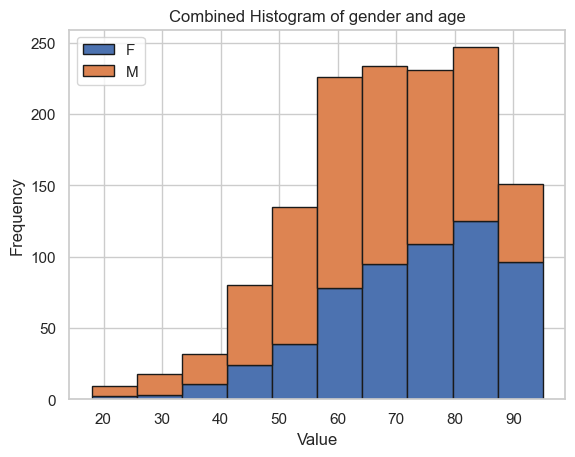

In [71]:
def check_missing_values(df):
    missing_values = df.isnull().sum()
    print("Missing values per column:")
    print(missing_values)
    
    
def distribution_analysis(df, column):
    distribution = df[column].value_counts(normalize=True) * 100
    print(f"Distribution of values in column '{column}':")
    print(distribution)

def plot_combined_histogram(df, category, ycolumn, n_bins=30):
    import matplotlib.pyplot as plt
    categories = df[category].dropna().unique()
    age_data = [df[df[category] == g][ycolumn] for g in categories]
    plt.hist(age_data, stacked=True,bins=n_bins, edgecolor='k', label=categories)
    plt.title(f'Combined Histogram of {category} and {ycolumn}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    

def plot_combined_histogram_edited(df, category, ycolumn, n_bins=30):
    import matplotlib.pyplot as plt
    import numpy as np

    categories = df[category].dropna().unique()
    colors = plt.cm.tab20b(np.linspace(0, 1, len(categories)))

    all_values = df[ycolumn].dropna()
    bins = np.linspace(all_values.min(), all_values.max(), n_bins + 1)
    counts_per_class = []

    for cat in categories:
        counts, _ = np.histogram(df.loc[df[category] == cat, ycolumn], bins=bins)
        counts_per_class.append(counts)

    counts_per_class = np.array(counts_per_class)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.figure(figsize=(10, 6))
    bottom = np.zeros(n_bins)

    for i, cat in enumerate(categories):
        plt.bar(
            bin_centers,
            counts_per_class[i],
            bottom=bottom,
            width=np.diff(bins)[0] * 0.9,
            color=colors[i],
            edgecolor='k',
            label=cat,
        )

        totals = counts_per_class.sum(axis=0)
        ratios = np.divide(
            counts_per_class[i],
            totals,
            out=np.zeros_like(counts_per_class[i], dtype=float),
            where=totals > 0,
        )

        for j in range(n_bins):
            if counts_per_class[i, j] > 0:
                y_pos = bottom[j] + counts_per_class[i, j] / 2
                plt.text(
                    bin_centers[j],
                    y_pos,
                    f"{counts_per_class[i, j]}\n{ratios[j]*100:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if ratios[j] > 0.15 else "black",  # contrast
                )

        bottom += counts_per_class[i]

    plt.title(f'Combined Histogram of {category} and {ycolumn}')
    plt.xlabel(ycolumn)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
#plot_histogram(heart_df, 'age')
#plot_class_distribution(heart_df, 'icd_code')
plot_combined_histogram(heart_df, 'gender', 'age', n_bins=10)

# Heart Measurements

This table contains clinical notes describing patients’ conditions and examination results. 
Diagnostic codes are also included. 
## Columns: 
- note_id: Unique identifier of the clinical note; 
-  subject_id: Unique patient identifier (also available in other CSV files);  
    ●  hadm_id: Hospital admission identifier (also available in other CSV files);  
    ●  note_type: Kind of note (discharge summary, progress note, ...);  
    ●  note_seq: Sequence number, only if multiple notes are recorded for the same 
admission id;  
    ●  charttime: Timestamp when the note was written;  
    ●  storetime: Timestamp when the note was stored. It may be at the same time of 
charttime or later;  
    ●  HPI: History of Present Illness (text); 
    ●  information about the subject, such as the age or the date of death;  
    ●  physical_exam: Textual description of the findings of physical examination;  
    ●  chief_complaint: Principal patient complaint reported at admission;  
    ●   invasions, X-ray, CT, Ultrasound, CATH, ECG, MRI: Indicators for examinations or 
procedures performed;  
    ●  reports: Reports, separated by "|" if more are available;  
    ●  icd_code: Diagnostic code (ICD-9 or ICD-10);  
    ●  long_title: Description of the diagnosis code

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype, is_bool_dtype
import math

def plot_patient_profile_panel_v2(df, cols_per_row=3, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    
    sample_df = df.sample(min(len(df), 1000)) if len(df) > 1000 else df
    
    valid_cols = []
    for col in df.columns:
        if col in exclude_cols: continue
        if df[col].dtype == 'object':
            if sample_df[col].astype(str).str.len().mean() > 50: 
                continue
        valid_cols.append(col)

    n_cols = len(valid_cols)
    if n_cols == 0: return
    n_rows = math.ceil(n_cols / cols_per_row)
    
    sns.set_style("ticks") 
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 5, n_rows * 4))
    axes = axes.flatten() if n_cols > 1 else [axes]

    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        if is_numeric_dtype(df[col]) and not is_bool_dtype(df[col]):
            sns.histplot(df[col], bins=30, ax=ax, color="#4c72b0", edgecolor="white", 
                         kde=True, line_kws={"color": "#c44e52", "lw": 2})
            ax.set_title(f"Distribution: {col}", fontsize=11, fontweight='bold')
            
        else:
            plot_data = df[col].fillna("NULL/MISSING")
            counts = plot_data.value_counts().head(10)
            labels = [str(x)[:15] + '..' if len(str(x)) > 15 else str(x) for x in counts.index]
            
            sns.barplot(x=labels, y=counts.values, ax=ax, color="#555e7b", alpha=0.85)
            ax.set_title(f"Frequency: {col}", fontsize=11, fontweight='bold')
            ax.tick_params(axis='x', rotation=45, labelsize=9)

        sns.despine(ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

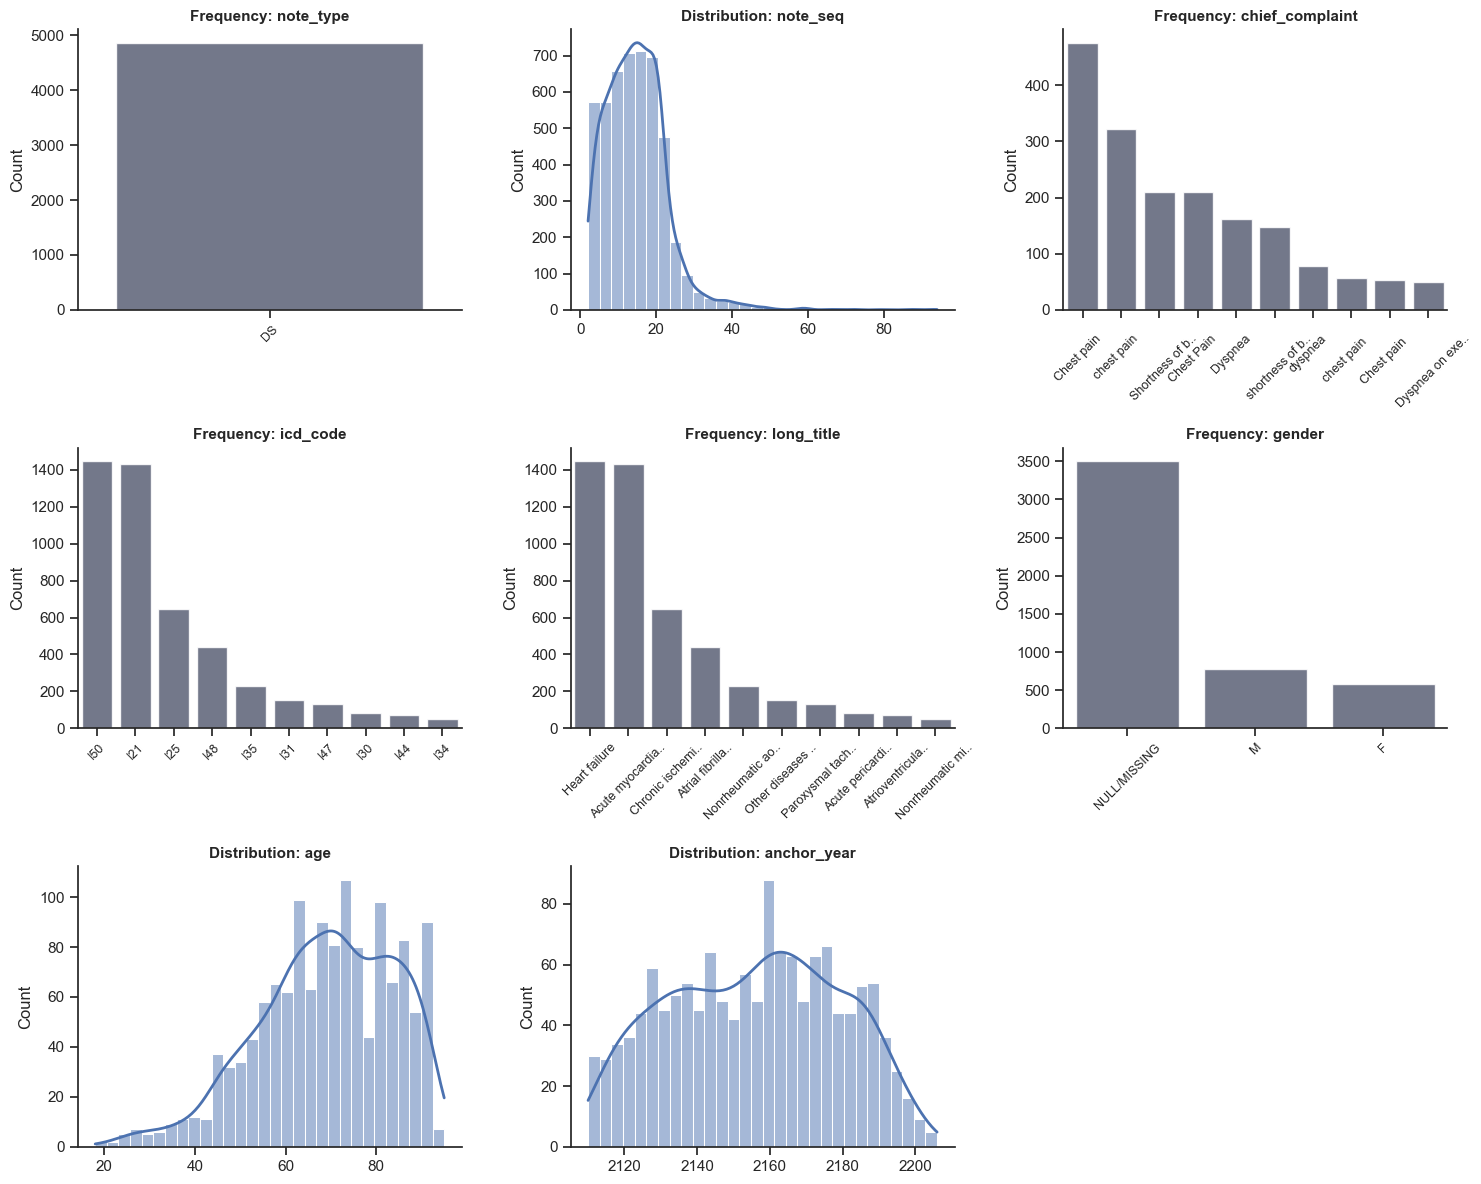

In [73]:
plot_patient_profile_panel_v2(heart_df, exclude_cols=['note_id', 'dod', 'subject_id', 'subject_id_dx', 'hadm_id', 'charttime', 'storetime', 'MRI'])

# Laboratory Events



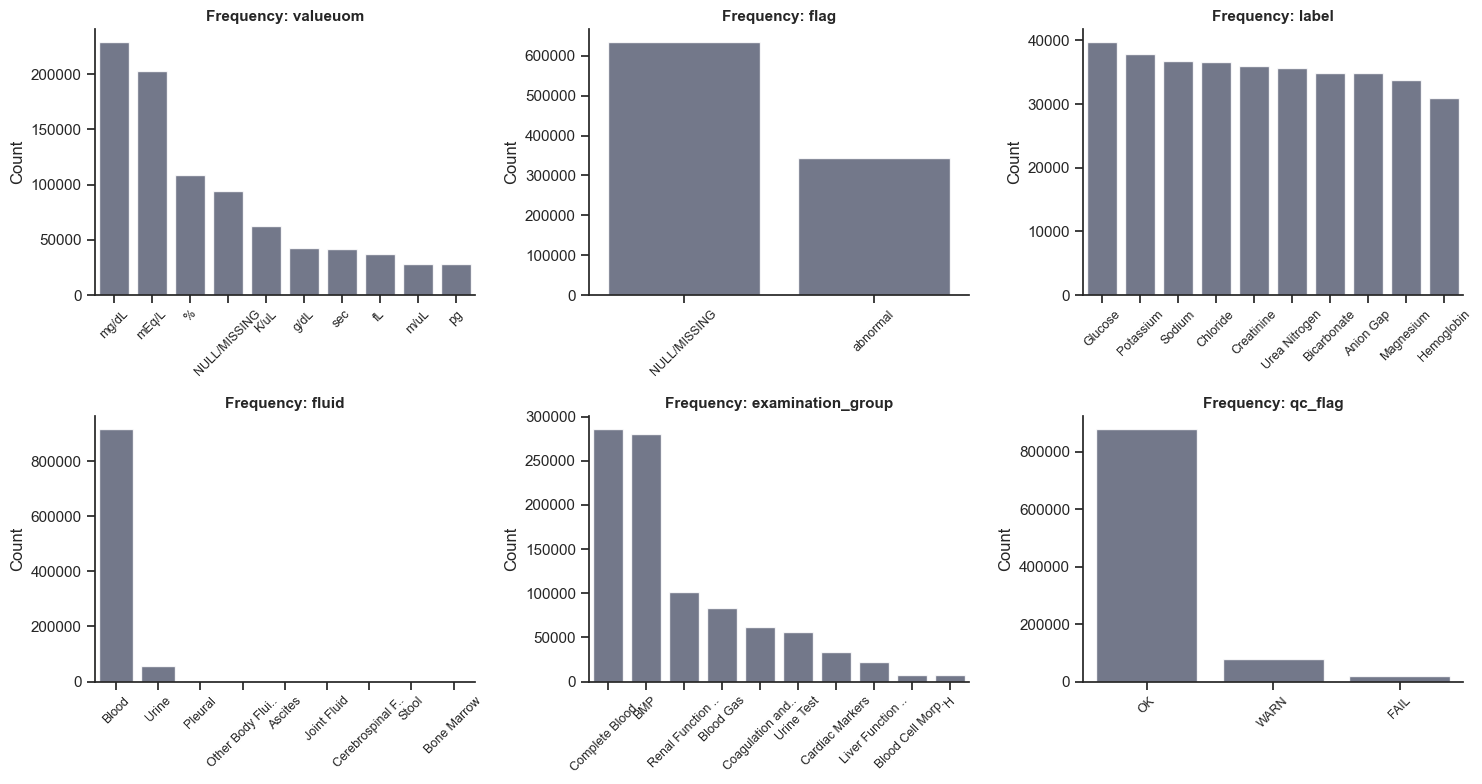

In [74]:
plot_patient_profile_panel_v2(laboratory_df, exclude_cols=['value', 'valuenum', 'hadm_id', 'charttime', 'ref_range_lower', 'ref_range_upper', 'analysis_batch_id', 'ref_range'])

In [75]:
print(laboratory_df.isnull().any())
laboratory_df['label'].unique()


hadm_id              False
charttime            False
value                 True
valuenum              True
valueuom              True
ref_range_lower       True
ref_range_upper       True
flag                  True
label                False
fluid                False
examination_group    False
analysis_batch_id    False
qc_flag              False
ref_range             True
dtype: bool


array(['Creatine Kinase (CK)', 'Creatine Kinase, MB Isoenzyme',
       'Troponin T', 'INR(PT)', 'PT', 'PTT', '% Hemoglobin A1c', 'eAG',
       'Anion Gap', 'Bicarbonate', 'Calcium, Total', 'Chloride',
       'Cholesterol Ratio (Total/HDL)', 'Cholesterol, HDL',
       'Cholesterol, LDL, Calculated', 'Cholesterol, Total', 'Creatinine',
       'Glucose', 'Magnesium', 'Phosphate', 'Potassium', 'Sodium',
       'Triglycerides', 'Urea Nitrogen', 'Hematocrit', 'Hemoglobin',
       'MCH', 'MCHC', 'MCV', 'Platelet Count', 'RDW', 'Red Blood Cells',
       'White Blood Cells', 'Alanine Aminotransferase (ALT)',
       'Asparate Aminotransferase (AST)', 'Albumin',
       'Alkaline Phosphatase', 'Amylase', 'Bilirubin, Direct',
       'Bilirubin, Indirect', 'Bilirubin, Total', 'Vitamin B12',
       'Basophils', 'Eosinophils', 'Lymphocytes', 'Monocytes',
       'Neutrophils', 'EDTA Hold', 'Red Top Hold', 'CK-MB Index',
       'Thyroid Stimulating Hormone', 'Thyroxine (T4), Free',
       'Base Excess',

In [76]:
laboratory_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 978501 entries, 0 to 978502
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   hadm_id            978501 non-null  float64
 1   charttime          978501 non-null  object 
 2   value              934025 non-null  object 
 3   valuenum           907317 non-null  float64
 4   valueuom           884585 non-null  object 
 5   ref_range_lower    865544 non-null  float64
 6   ref_range_upper    865544 non-null  float64
 7   flag               343687 non-null  object 
 8   label              978501 non-null  object 
 9   fluid              978501 non-null  object 
 10  examination_group  978501 non-null  object 
 11  analysis_batch_id  978501 non-null  object 
 12  qc_flag            978501 non-null  object 
 13  ref_range          146215 non-null  object 
dtypes: float64(4), object(10)
memory usage: 112.0+ MB


In [77]:

laboratory_df.describe()

,hadm_id,valuenum,ref_range_lower,ref_range_upper
count,9.785010e+05,907317.000000,865544.000000,865544.000000
mean,2.504395e+07,67.332325,31.724619,55.794861
std,2.868159e+06,2175.589189,44.840840,400.515033
min,2.000446e+07,-743.000000,0.000000,0.000000
25%,2.261232e+07,4.300000,3.300000,5.400000
50%,2.510567e+07,17.000000,10.400000,20.000000
75%,2.749772e+07,60.200000,36.000000,52.000000
max,2.999967e+07,886449.000000,2200.000000,100000.000000


In [78]:
drop_duplicates(laboratory_df)

Original shape: (978501, 14)
New shape: (978501, 14)


,hadm_id,charttime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,label,fluid,examination_group,analysis_batch_id,qc_flag,ref_range
0,29654838.0,2188-01-04 23:43:00,___,198.00,IU/L,29.0,201.00,NaN,Creatine Kinase (CK),Blood,Cardiac Markers,BATCH_218801_N3,OK,NaN
1,29654838.0,2188-01-04 23:43:00,5,5.00,ng/mL,0.0,10.00,NaN,"Creatine Kinase, MB Isoenzyme",Blood,Cardiac Markers,BATCH_218801_C7,OK,NaN
2,29654838.0,2188-01-04 23:43:00,___,0.03,ng/mL,0.0,0.01,abnormal,Troponin T,Blood,Cardiac Markers,BATCH_218801_R4,OK,NaN
3,29654838.0,2188-01-05 06:56:00,1.2,1.20,NaN,0.9,1.10,abnormal,INR(PT),Blood,Coagulation and Hemostasis,BATCH_218801_K7,OK,NaN
4,29654838.0,2188-01-05 06:56:00,12.8,12.80,sec,9.4,12.50,abnormal,PT,Blood,Coagulation and Hemostasis,BATCH_218801_B1,WARN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978498,21557581.0,2145-08-02 08:30:00,180,180.00,K/uL,150.0,400.00,NaN,Platelet Count,Blood,Complete Blood Count (CBC),BATCH_214508_B1,OK,NaN
978499,21557581.0,2145-08-02 08:30:00,14.5,14.50,%,10.5,15.50,NaN,RDW,Blood,Complete Blood Count (CBC),BATCH_214508_H5,OK,NaN
978500,21557581.0,2145-08-02 08:30:00,3.26,3.26,m/uL,3.9,5.20,abnormal,Red Blood Cells,Blood,Complete Blood Count (CBC),BATCH_214508_N7,OK,NaN
978501,21557581.0,2145-08-02 08:30:00,8.4,8.40,K/uL,4.0,10.00,NaN,White Blood Cells,Blood,Complete Blood Count (CBC),BATCH_214508_Y6,OK,NaN


In [79]:
laboratory_df.loc[laboratory_df['hadm_id'] == 29765478.0]
laboratory_df.loc[laboratory_df['label'] == 'Creatinine']
laboratory_df['label'].unique()

array(['Creatine Kinase (CK)', 'Creatine Kinase, MB Isoenzyme',
       'Troponin T', 'INR(PT)', 'PT', 'PTT', '% Hemoglobin A1c', 'eAG',
       'Anion Gap', 'Bicarbonate', 'Calcium, Total', 'Chloride',
       'Cholesterol Ratio (Total/HDL)', 'Cholesterol, HDL',
       'Cholesterol, LDL, Calculated', 'Cholesterol, Total', 'Creatinine',
       'Glucose', 'Magnesium', 'Phosphate', 'Potassium', 'Sodium',
       'Triglycerides', 'Urea Nitrogen', 'Hematocrit', 'Hemoglobin',
       'MCH', 'MCHC', 'MCV', 'Platelet Count', 'RDW', 'Red Blood Cells',
       'White Blood Cells', 'Alanine Aminotransferase (ALT)',
       'Asparate Aminotransferase (AST)', 'Albumin',
       'Alkaline Phosphatase', 'Amylase', 'Bilirubin, Direct',
       'Bilirubin, Indirect', 'Bilirubin, Total', 'Vitamin B12',
       'Basophils', 'Eosinophils', 'Lymphocytes', 'Monocytes',
       'Neutrophils', 'EDTA Hold', 'Red Top Hold', 'CK-MB Index',
       'Thyroid Stimulating Hormone', 'Thyroxine (T4), Free',
       'Base Excess',

In [80]:
filtered_df = laboratory_df.loc[laboratory_df["label"] == "Creatine Kinase (CK)"]
print (filtered_df)
print(filtered_df.describe())


           hadm_id            charttime value  valuenum valueuom  \
0       29654838.0  2188-01-04 23:43:00   ___     198.0     IU/L   
16      29654838.0  2188-01-05 06:56:00   ___     173.0     IU/L   
59      26913865.0  2189-06-28 15:58:00   ___     263.0     IU/L   
107     26913865.0  2189-06-29 14:00:00   ___     205.0     IU/L   
235     24760295.0  2160-07-12 10:15:00   ___      52.0     IU/L   
...            ...                  ...   ...       ...      ...   
975407  27777812.0  2143-03-09 16:14:00   ___     922.0     IU/L   
975499  27777812.0  2143-03-10 06:09:00   ___     550.0     IU/L   
975656  27777812.0  2143-03-10 19:46:00   ___     512.0     IU/L   
977035  25021512.0  2141-01-20 08:30:00   ___      81.0     IU/L   
977525  28847872.0  2123-12-30 04:59:00   ___     438.0     IU/L   

        ref_range_lower  ref_range_upper      flag                 label  \
0                  29.0            201.0       NaN  Creatine Kinase (CK)   
16                 29.0        

In [81]:
len(laboratory_df["label"].unique())
len(laboratory_df["fluid"].unique())
laboratory_df['fluid'].unique()

array(['Blood', 'Urine', 'Other Body Fluid', 'Pleural', 'Ascites',
       'Cerebrospinal Fluid', 'Stool', 'Joint Fluid', 'Bone Marrow'],
      dtype=object)

# Microbiology

In [82]:
microbiology_df.columns

Index(['subject_id', 'hadm_id', 'chartdate', 'charttime', 'spec_type_desc',
       'test_name', 'org_name', 'ab_name', 'dilution_text',
       'dilution_comparison', 'dilution_value', 'interpretation',
       'technician_id', 'qc_flag'],
      dtype='object')

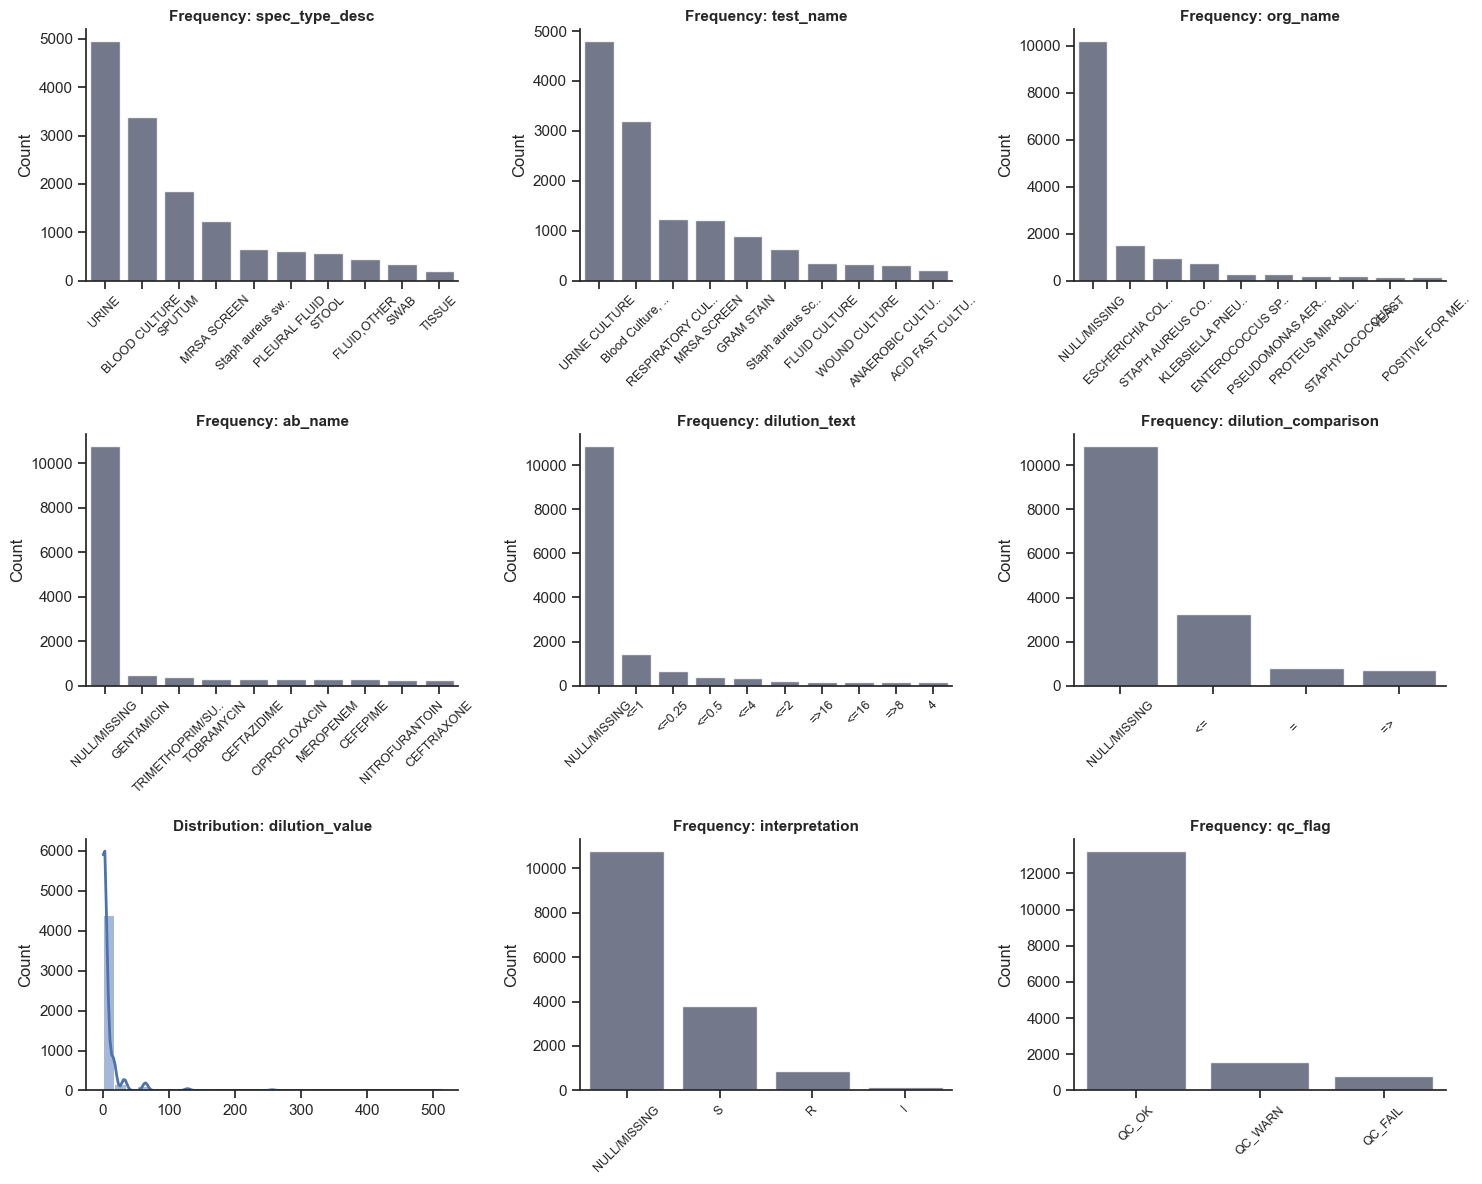

         2118709 function calls (2055511 primitive calls) in 3.158 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     4078    0.260    0.000    0.261    0.000 transforms.py:179(set_children)
    23784    0.076    0.000    0.076    0.000 {method 'reduce' of 'numpy.ufunc' objects}
   1676/1    0.064    0.000    0.004    0.004 text.py:358(_get_layout)
20300/348    0.063    0.000    0.112    0.000 copy.py:119(deepcopy)
        3    0.053    0.018    0.053    0.018 {method 'encode' of 'ImagingEncoder' objects}
149193/148843    0.053    0.000    0.084    0.000 {built-in method builtins.isinstance}
      862    0.047    0.000    0.089    0.000 lines.py:758(draw)
73409/73169    0.041    0.000    0.089    0.000 {built-in method builtins.getattr}
     7223    0.037    0.000    0.071    0.000 artist.py:414(pchanged)
     3626    0.035    0.000    0.198    0.000 artist.py:1188(_update_props)
    11579    0.035    0.000    0.051    0.

In [83]:
%prun plot_patient_profile_panel_v2(microbiology_df, exclude_cols=['subject_id', 'hadm_id', 'charttime', 'chartdate', 'technician_id'])

In [84]:
microbiology_df.isnull().any()

subject_id             False
hadm_id                False
chartdate              False
charttime              False
spec_type_desc         False
test_name              False
org_name                True
ab_name                 True
dilution_text           True
dilution_comparison     True
dilution_value          True
interpretation          True
technician_id          False
qc_flag                False
dtype: bool

In [85]:
microbiology_df.describe()

,subject_id,hadm_id,dilution_value
count,1.558600e+04,1.558600e+04,4711.000000
mean,1.522120e+07,2.503479e+07,7.062420
std,2.910205e+06,2.846429e+06,21.245298
min,1.000098e+07,2.000790e+07,0.060000
25%,1.266277e+07,2.266230e+07,0.500000
50%,1.519823e+07,2.514649e+07,1.000000
75%,1.772189e+07,2.743116e+07,4.000000
max,1.999767e+07,2.999967e+07,512.000000


In [86]:
drop_duplicates(microbiology_df)

Original shape: (15586, 14)
New shape: (15586, 14)


,subject_id,hadm_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
0,10000980,26913865.0,2189-06-27 00:00:00,2189-06-27 10:52:00,MRSA SCREEN,MRSA SCREEN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_063,QC_OK
1,10002155,23822395.0,2129-08-04 00:00:00,2129-08-04 17:04:00,MRSA SCREEN,MRSA SCREEN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_095,QC_OK
2,10002155,23822395.0,2129-08-05 00:00:00,2129-08-05 15:54:00,URINE,Legionella Urinary Antigen,NaN,NaN,NaN,NaN,NaN,NaN,TECH_083,QC_OK
3,10002155,23822395.0,2129-08-05 00:00:00,2129-08-05 18:43:00,SPUTUM,GRAM STAIN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_095,QC_OK
4,10002155,23822395.0,2129-08-05 00:00:00,2129-08-05 18:43:00,SPUTUM,RESPIRATORY CULTURE,NaN,NaN,NaN,NaN,NaN,NaN,TECH_077,QC_OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15582,19997665,26052266.0,2173-11-09 00:00:00,2173-11-09 18:09:00,Staph aureus swab,Staph aureus Screen,NaN,NaN,NaN,NaN,NaN,NaN,TECH_051,QC_OK
15583,19997666,24256422.0,2168-08-03 00:00:00,2168-08-03 22:00:00,BLOOD CULTURE,"Blood Culture, Routine",NaN,NaN,NaN,NaN,NaN,NaN,TECH_086,QC_OK
15584,19997667,20372003.0,2144-09-21 00:00:00,2144-09-21 20:14:00,URINE,URINE CULTURE,PSEUDOMONAS AERUGINOSA,MEROPENEM,8,=,8.0,I,TECH_115,QC_FAIL
15585,19997668,20329436.0,2129-08-12 00:00:00,2129-08-12 15:56:00,CATHETER TIP-IV,WOUND CULTURE,NaN,NaN,NaN,NaN,NaN,NaN,TECH_061,QC_OK


In [87]:
len(microbiology_df["org_name"].unique())
microbiology_df['org_name'].value_counts()

org_name
ESCHERICHIA COLI                                  1508
STAPH AUREUS COAG +                                966
KLEBSIELLA PNEUMONIAE                              763
ENTEROCOCCUS SP.                                   267
PSEUDOMONAS AERUGINOSA                             264
                                                  ... 
PENICILLIUM SPECIES                                  1
LACTOBACILLUS SPECIES                                1
ASPERGILLUS SP. NOT FUMIGATUS, FLAVUS OR NIGER       1
HERPES SIMPLEX VIRUS TYPE 1                          1
STAPHYLOCOCCUS SPECIES                               1
Name: count, Length: 82, dtype: int64

# Procedure Codes

In [88]:
procedures_df

,subject_id,hadm_id,seq_num,chartdate,icd_code,long_title
0,10000980,26913865,1,2189-07-01 03:00:00,0066,Percutaneous transluminal coronary angioplasty...
1,10000980,26913865,2,2189-07-01 03:00:00,3607,Insertion of drug-eluting coronary artery sten...
2,10000980,26913865,3,2189-07-01 03:00:00,0045,Insertion of one vascular stent
3,10000980,26913865,4,2189-07-01 03:00:00,0041,Procedure on two vessels
4,10000980,26913865,5,2189-07-01 03:00:00,3722,Left heart cardiac catheterization
...,...,...,...,...,...,...
14492,19998497,21557581,1,2145-07-29 03:00:00,0066,Percutaneous transluminal coronary angioplasty...
14493,19998497,21557581,2,2145-07-29 03:00:00,3607,Insertion of drug-eluting coronary artery sten...
14494,19998497,21557581,3,2145-07-29 03:00:00,0045,Insertion of one vascular stent
14495,19998497,21557581,4,2145-07-29 03:00:00,0040,Procedure on single vessel


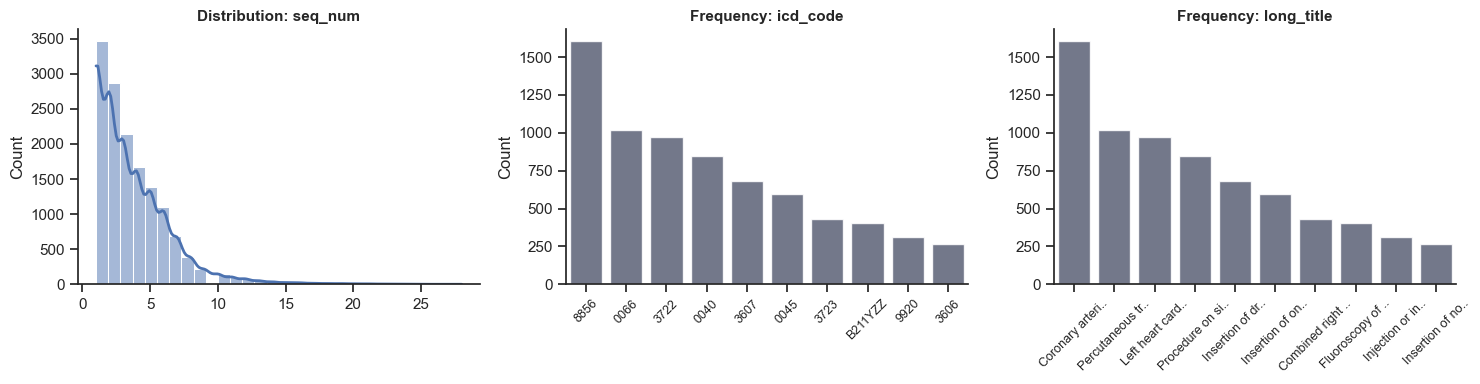

In [89]:
plot_patient_profile_panel_v2(procedures_df, exclude_cols=['subject_id', 'hadm_id', 'chartdate'])

In [90]:
procedures_df.describe()

,subject_id,hadm_id,seq_num
count,1.449700e+04,1.449700e+04,14497.000000
mean,1.496070e+07,2.506208e+07,3.661102
std,2.892130e+06,2.857570e+06,2.841640
min,1.000098e+07,2.000790e+07,1.000000
25%,1.249274e+07,2.268042e+07,2.000000
50%,1.486272e+07,2.507288e+07,3.000000
75%,1.745891e+07,2.750236e+07,5.000000
max,1.999850e+07,2.999967e+07,28.000000


# Correlation Analysis for Raw Datasets

In [91]:
id_cols = ["subject_id", "hadm_id", "subject_id_dx"]

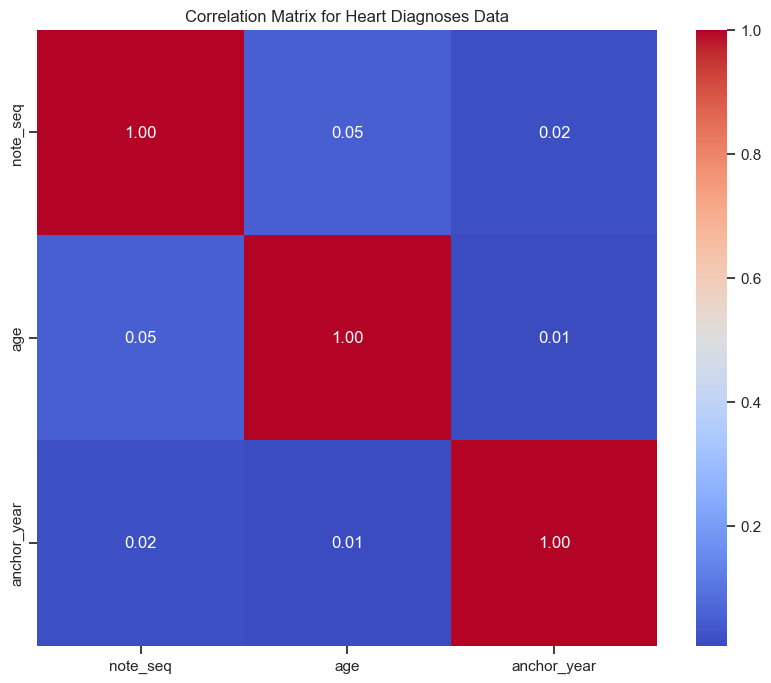

In [92]:
heart_df = heart_df.drop(columns=id_cols, errors="ignore")
heart_corr = heart_df.corr(numeric_only=True)

def plot_correlation_matrix(corr_matrix, title="Correlation Matrix"):
     plt.figure(figsize=(10, 8))
     sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
     plt.title(title)
     plt.show()
     
plot_correlation_matrix(heart_corr, title="Correlation Matrix for Heart Diagnoses Data")


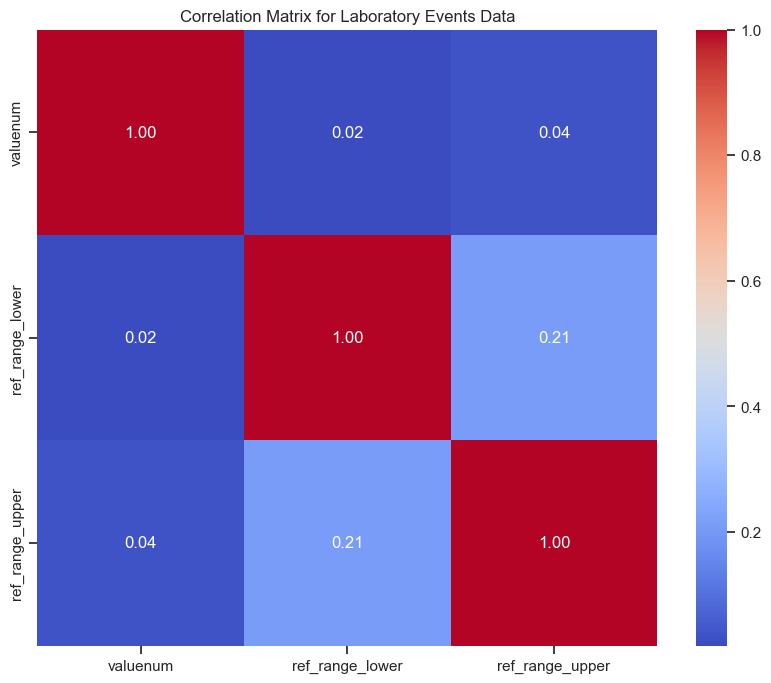

In [93]:
laboratory_df = laboratory_df.drop(columns=id_cols, errors='ignore')
plot_correlation_matrix(laboratory_df.corr(numeric_only=True), title="Correlation Matrix for Laboratory Events Data")

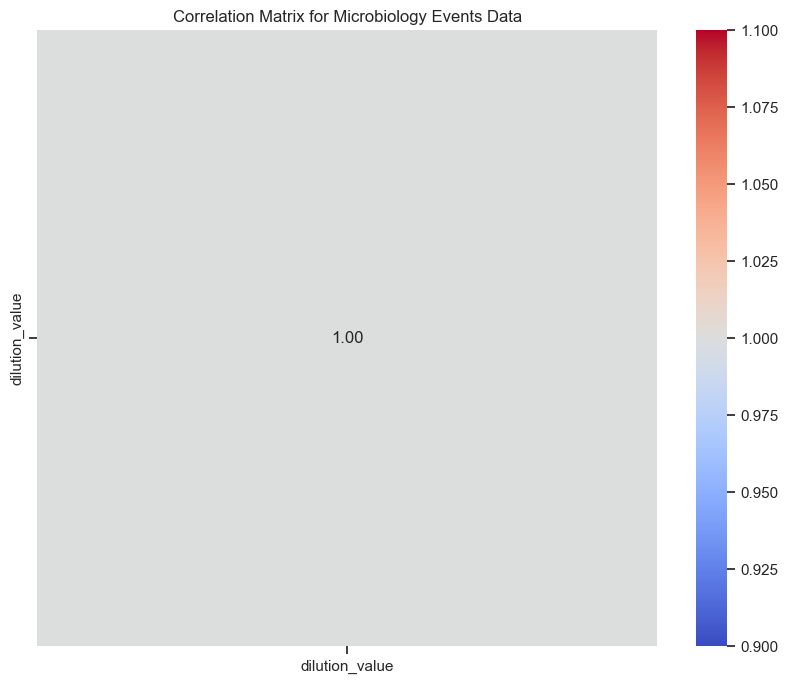

In [94]:
microbiology_df = microbiology_df.drop(columns=id_cols, errors='ignore')
plot_correlation_matrix(microbiology_df.corr(numeric_only=True), title="Correlation Matrix for Microbiology Events Data")

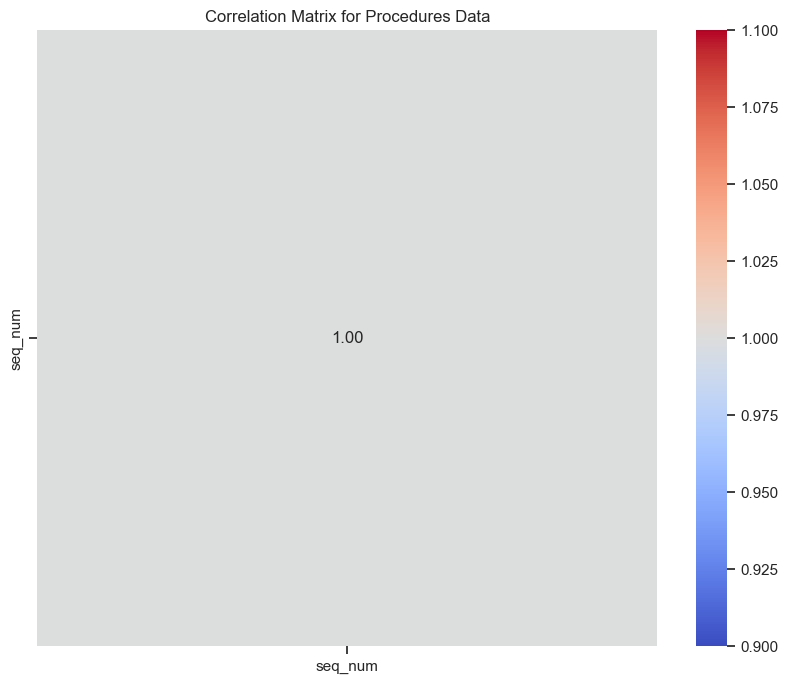

In [95]:
procedures_df = procedures_df.drop(columns=id_cols, errors='ignore')
plot_correlation_matrix(procedures_df.corr(numeric_only=True), title="Correlation Matrix for Procedures Data")

# --- PART 2: Data Preparation ---


# 2.1 Creating the Patient Profile

 This notebook transforms the raw multi-file dataset into a single, comprehensive `patient_profile.csv` file.

To create a correct profile, we must identify the unique key for each record: **(`subject_id`, `hadm_id`)**.

We initialize our profile using the `heart_diagnoses.csv` file, which contains the master list of admissions.

**Why we choose this:** At this first step, we capture the core patient demographics: **Age** and **Gender**. These are fundamental features for any patient-based clustering or classification model, as outcomes and patient state are highly dependent on them.


In [96]:
# remove admissions that will have duplicated feature sets
def remove_duplicated_admissions(df_profile):
    duplicated_admissions = df_profile["hadm_id"].value_counts()[df_profile["hadm_id"].value_counts() > 1].index
    return df_profile[~df_profile["hadm_id"].isin(duplicated_admissions)].reset_index(drop=True)

In [97]:

print("Loading raw data files...")
try:
    df_lab = pd.read_csv("../Data/laboratory_events_codes_2.csv")
    df_heart = pd.read_csv("../Data/heart_diagnoses_1.csv")
    df_micro = pd.read_csv("../Data/microbiology_events_codes_3.csv")
    df_proc = pd.read_csv("../Data/procedure_code_4.csv")
    print(" files loaded successfully.")

    
    print("Cleaning raw files: Dropping exact duplicates...")
    
    lab_rows_before = len(df_lab)
    heart_rows_before = len(df_heart)
    micro_rows_before = len(df_micro)
    proc_rows_before = len(df_proc)

    df_lab = df_lab.drop_duplicates()
    
    df_heart = df_heart.drop_duplicates()
    
    df_micro = df_micro.drop_duplicates()
    df_proc = df_proc.drop_duplicates()
    print("Dropping hadm_id collisions...")
    df_heart = remove_duplicated_admissions(df_heart)
    print(f"  Lab: Removed {lab_rows_before - len(df_lab)} duplicate rows.")
    print(f"  Heart: Removed {heart_rows_before - len(df_heart)} duplicate rows including rows with hadm_id collision.")
    print(f"  Micro: Removed {micro_rows_before - len(df_micro)} duplicate rows.")
    print(f"  Proc: Removed {proc_rows_before - len(df_proc)} duplicate rows.")

except FileNotFoundError as e:
    print(f" ERROR: {e}")
    print("Please ensure all 4 CSV files are in the ../Data/ folder.")

Loading raw data files...
 files loaded successfully.
Cleaning raw files: Dropping exact duplicates...
Dropping hadm_id collisions...
  Lab: Removed 2 duplicate rows.
  Heart: Removed 204 duplicate rows including rows with hadm_id collision.
  Micro: Removed 1 duplicate rows.
  Proc: Removed 0 duplicate rows.


# remove FAIL and WARN Lab results

In [98]:
failed = df_lab[df_lab['qc_flag'] == "FAIL"]
warned = df_lab[df_lab['qc_flag'] == "WARN"]
# remove failed records
df_lab = df_lab[df_lab['qc_flag'] != "FAIL"]
df_lab = df_lab[df_lab['qc_flag'] != "WARN"]
print(f"Lab Events with QC_FLAG == FAIL: {len(failed)}")
print(f"Lab Events with QC_FLAG == WARN: {len(warned)}")

Lab Events with QC_FLAG == FAIL: 19570
Lab Events with QC_FLAG == WARN: 78124


In [99]:
print("Initializing Patient Profile...")

profile_cols = ['subject_id', 'hadm_id', 'age', 'gender']
df_patient_profile = df_heart[profile_cols].drop_duplicates().reset_index(drop=True)

print(f"Unique Subject-Admission Pairs initialized: {len(df_patient_profile)}")
df_patient_profile.head()

Initializing Patient Profile...
Unique Subject-Admission Pairs initialized: 4660


,subject_id,hadm_id,age,gender
0,10000980,29654838,75.0,F
1,10000980,26913865,75.0,F
2,10002013,24760295,NaN,NaN
3,10002155,23822395,NaN,NaN
4,10004457,28723315,66.0,M


## 2.2 Creating the Patient Profile
 Feature Engineering: Laboratory Events

We now extract critical indicators from the lab events.

**Why we choose these features:** We go beyond the generic `max_glucose` to build a richer profile. Since the project is focused on **heart diagnoses**, we add:

1.  **Max Troponin:** The primary biomarker for heart muscle damage. This is the most *clinically significant* lab value for our specific study.
2.  **Max WBC (White Blood Cell):** A key proxy for infection and inflammation, which are major factors in patient severity and complexity.
3.  **Total Lab Events & Abnormal Ratio:** Kept as measures of monitoring intensity and overall test abnormality.
4.  **Max Creatinine:** A biomarker that might indicate kidney disfunction.
5.  **Electrolytes:** `max_potassium` (Arrhythmia risk)
6.  **Nutrition/Liver:** `min_albumin` (Frailty and chronic health)
7.  **Chronic Metabolic:** `max_hba1c` (Long-term diabetes control)
8.  **Hematology:** `min_platelet` (Bleeding risk)

* `lab_events.csv` uses `hadm_id`. We aggregate by `hadm_id` and merge left.*

In [100]:
# calc defaults for fluid and valueom before for better performance
lab_defaults = df_lab.groupby('label')[['fluid', 'valueuom']].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).to_dict('index')

# calc features
def getSubset(df, label):
    d = lab_defaults.get(label)
    if not d:
        return df[df['label'] == label]
    return df[(df['label'] == label) & 
              (df['fluid'] == d['fluid']) & 
              (df['valueuom'] == d['valueuom'])]

# calc features
df_glucose = getSubset(df_lab, 'Glucose')
df_troponin = getSubset(df_lab, 'Troponin T')
df_creatinine = getSubset(df_lab, 'Creatinine')
df_wbc = getSubset(df_lab, 'White Blood Cells')
df_potassium = getSubset(df_lab, 'Potassium')
df_hba1c = getSubset(df_lab, '% Hemoglobin A1c')
df_albumin = getSubset(df_lab, 'Albumin')
df_platelet = getSubset(df_lab, 'Platelet Count')

lab_agg = df_lab.groupby('hadm_id').agg(
    total_lab_events=('valuenum', 'count'),
    abnormal_count=('flag', lambda x: (x == 'abnormal').sum())
)

lab_agg['max_glucose'] = df_glucose.groupby('hadm_id')['valuenum'].max()
lab_agg['max_troponin'] = df_troponin.groupby('hadm_id')['valuenum'].max()
lab_agg['max_creatinine'] = df_creatinine.groupby('hadm_id')['valuenum'].max()
lab_agg['max_wbc'] = df_wbc.groupby('hadm_id')['valuenum'].max()
lab_agg['max_potassium'] = df_potassium.groupby('hadm_id')['valuenum'].max()
lab_agg['max_hba1c'] = df_hba1c.groupby('hadm_id')['valuenum'].max()
lab_agg['min_albumin'] = df_albumin.groupby('hadm_id')['valuenum'].min()
lab_agg['min_platelet'] = df_platelet.groupby('hadm_id')['valuenum'].min()

lab_agg = lab_agg.reset_index()
lab_agg['abnormal_ratio'] = lab_agg['abnormal_count'] / lab_agg['total_lab_events']

cols_to_merge = [
    'hadm_id', 'total_lab_events', 'abnormal_ratio',
    'max_glucose', 'max_troponin', 'max_wbc', 'max_creatinine',
    'max_potassium', 'max_hba1c', 'min_albumin', 'min_platelet' 
]

df_patient_profile = df_patient_profile.merge(
    lab_agg[cols_to_merge], 
    on='hadm_id', 
    how='left'
)

print("Merged Lab Features. Verification:")
#print(df_patient_profile[['max_potassium', 'min_albumin', 'max_hba1c', 'min_platelet']].head())
df_patient_profile

Merged Lab Features. Verification:


,subject_id,hadm_id,age,gender,total_lab_events,abnormal_ratio,max_glucose,max_troponin,max_wbc,max_creatinine,max_potassium,max_hba1c,min_albumin,min_platelet
0,10000980,29654838,75.0,F,55.0,0.400000,138.0,0.04,4.9,1.4,4.5,8.1,NaN,175.0
1,10000980,26913865,75.0,F,150.0,0.400000,163.0,0.15,6.3,2.3,4.5,6.8,4.1,180.0
2,10002013,24760295,NaN,NaN,45.0,0.333333,395.0,0.13,9.0,1.0,3.6,NaN,NaN,263.0
3,10002155,23822395,NaN,NaN,337.0,0.335312,140.0,3.99,7.5,1.2,5.6,NaN,NaN,136.0
4,10004457,28723315,66.0,M,24.0,0.250000,92.0,NaN,6.5,1.0,5.1,NaN,NaN,265.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,19993951,29858732,72.0,M,286.0,0.398601,141.0,NaN,4.6,1.9,4.9,NaN,4.1,107.0
4656,19994505,22534556,NaN,NaN,89.0,0.247191,156.0,NaN,8.2,1.2,4.5,6.7,4.1,144.0
4657,19997293,28847872,NaN,NaN,418.0,0.485646,201.0,0.96,19.7,2.2,6.3,NaN,NaN,272.0
4658,19997367,24169669,63.0,F,241.0,0.601660,176.0,NaN,8.2,3.2,6.1,NaN,NaN,142.0


## 2.3 Feature Engineering: Microbiology 

We analyze `microbiology_events.csv`. In addition to the total count, we define a **Custom Indicator** as required by the project.

### Defined Indicator 1: Resistant Organism Count
* **Definition:** The count of microbiology tests where the interpretation was 'R' (Resistant).
* **Objective:** This variable serves as a proxy for **infection severity and treatment difficulty**.

In [101]:
print("Processing Microbiology...")

# 1. Aggregate Total Events (Group by BOTH IDs)
micro_count = df_micro.groupby(['subject_id', 'hadm_id']).size().to_frame(name='total_microbio_events').reset_index()

# 2. Aggregate Resistant Count (Custom Feature)
resistant_events = df_micro[df_micro['interpretation'] == 'R']
resistant_count = resistant_events.groupby(['subject_id', 'hadm_id']).size().to_frame(name='resistant_count').reset_index()

# 3. --- NEW FEATURE: Distinct Organisms ---
# We count the number of unique, non-null organism names for the admission
distinct_orgs = df_micro.groupby(['subject_id', 'hadm_id'])['org_name'].nunique().to_frame(name='distinct_organisms').reset_index()

# 4. Merge all
df_patient_profile = df_patient_profile.merge(micro_count, on=['subject_id', 'hadm_id'], how='left')
df_patient_profile = df_patient_profile.merge(resistant_count, on=['subject_id', 'hadm_id'], how='left')
df_patient_profile = df_patient_profile.merge(distinct_orgs, on=['subject_id', 'hadm_id'], how='left') # <-- Merge new feature

df_patient_profile.head()

Processing Microbiology...


,subject_id,hadm_id,age,gender,total_lab_events,abnormal_ratio,max_glucose,max_troponin,max_wbc,max_creatinine,max_potassium,max_hba1c,min_albumin,min_platelet,total_microbio_events,resistant_count,distinct_organisms
0,10000980,29654838,75.0,F,55.0,0.400000,138.0,0.04,4.9,1.4,4.5,8.1,NaN,175.0,NaN,NaN,NaN
1,10000980,26913865,75.0,F,150.0,0.400000,163.0,0.15,6.3,2.3,4.5,6.8,4.1,180.0,1.0,NaN,0.0
2,10002013,24760295,NaN,NaN,45.0,0.333333,395.0,0.13,9.0,1.0,3.6,NaN,NaN,263.0,NaN,NaN,NaN
3,10002155,23822395,NaN,NaN,337.0,0.335312,140.0,3.99,7.5,1.2,5.6,NaN,NaN,136.0,12.0,NaN,0.0
4,10004457,28723315,66.0,M,24.0,0.250000,92.0,NaN,6.5,1.0,5.1,NaN,NaN,265.0,NaN,NaN,NaN


## 2.4 Feature Engineering: Procedures & Diagnoses 

We analyze `procedure_codes.csv` and return to `heart_diagnoses.csv`.

### Defined Indicator 2: Diagnosis Complexity
* **Definition:** The total number of distinct diagnostic codes (ICD codes) associated with the admission.
* **Objective:** This variable quantifies **multimorbidity**. A higher number of diagnoses indicates a more complex patient status.

In [102]:
print("Processing Procedures & Diagnoses...")

# 1. Procedures 
proc_count = df_proc.groupby(['subject_id', 'hadm_id']).size().to_frame(name='total_procedures').reset_index()

# 2. Diagnosis Complexity 
#diag_count = df_heart.groupby(['subject_id', 'hadm_id']).size().to_frame(name='num_diagnoses').reset_index() # logic is not correct
# fixed num_diagnoses by calculating feature by subject id, as subject_id + hadm_id is unique
diag_count = df_heart.groupby(['subject_id'])['icd_code'].nunique().to_frame(name="num_diagnoses").reset_index()
diag_count

# 3. Merge
df_patient_profile = df_patient_profile.merge(proc_count, on=['subject_id', 'hadm_id'], how='left')
df_patient_profile = df_patient_profile.merge(diag_count, on=['subject_id'], how='left')

df_patient_profile.head()

Processing Procedures & Diagnoses...


,subject_id,hadm_id,age,gender,total_lab_events,abnormal_ratio,max_glucose,max_troponin,max_wbc,max_creatinine,max_potassium,max_hba1c,min_albumin,min_platelet,total_microbio_events,resistant_count,distinct_organisms,total_procedures,num_diagnoses
0,10000980,29654838,75.0,F,55.0,0.400000,138.0,0.04,4.9,1.4,4.5,8.1,NaN,175.0,NaN,NaN,NaN,NaN,2
1,10000980,26913865,75.0,F,150.0,0.400000,163.0,0.15,6.3,2.3,4.5,6.8,4.1,180.0,1.0,NaN,0.0,7.0,2
2,10002013,24760295,NaN,NaN,45.0,0.333333,395.0,0.13,9.0,1.0,3.6,NaN,NaN,263.0,NaN,NaN,NaN,2.0,1
3,10002155,23822395,NaN,NaN,337.0,0.335312,140.0,3.99,7.5,1.2,5.6,NaN,NaN,136.0,12.0,NaN,0.0,8.0,1
4,10004457,28723315,66.0,M,24.0,0.250000,92.0,NaN,6.5,1.0,5.1,NaN,NaN,265.0,NaN,NaN,NaN,NaN,1


##  Data Cleaning and Imputation 

After the left-merge, `NaN` values have different meanings depending on the feature type:

1) **Count-based features → fill with 0**  
   Examples: `total_procedures`, `total_lab_events`, `resistant_count`  
   Interpretation: `NaN` means no matching events for that admission.  
   Action: fill with `0`.

2) **Measurements and ratios → keep as NaN**  
   Examples: `max_glucose`, `max_troponin`, `max_wbc`, `abnormal_ratio`  
   Interpretation: `NaN` means the measurement was not available / not taken, or the ratio cannot be computed (e.g., division by zero).  
   Action: keep as `NaN` and handle later during preprocessing (e.g., median imputation).


In [103]:
print("Cleaning missing values (Imputing Counts to 0)...")

# 'abnormal_ratio' has been REMOVED from this list.
# 'distinct_organisms' has been ADDED.
cols_to_fill_zero = [
    'total_lab_events', 
    'total_microbio_events', 
    'resistant_count', 
    'total_procedures',
    'num_diagnoses',
    'distinct_organisms' 
]

# Fill NaNs with 0 for counts
df_patient_profile[cols_to_fill_zero] = df_patient_profile[cols_to_fill_zero].fillna(0)

print(" Counts imputed successfully.")

Cleaning missing values (Imputing Counts to 0)...
 Counts imputed successfully.


##  Feature Engineering: Ratios and Final Save

Now that all counts are merged and imputed (filled with 0), we can create powerful ratio features.

**Why we choose these features:** Ratios are often more significant than raw counts for clustering because they are **normalized** and comparable across patients.

1.  **Resistant Ratio:** (`resistant_count` / `total_microbio_events`). This is a powerful proxy for *infection complexity*.
2.  **Procedure-Diagnosis Ratio:** (`total_procedures` / `num_diagnoses`). This is a proxy for *intervention intensity*.

In [104]:
print("Creating ratio-based features...")

# 1. Resistant Ratio
df_patient_profile['resistant_ratio'] = 0.0
df_patient_profile.loc[df_patient_profile['total_microbio_events'] > 0, 'resistant_ratio'] = \
    df_patient_profile['resistant_count'] / df_patient_profile['total_microbio_events']

# 2. Procedure-Diagnosis Ratio
df_patient_profile['proc_per_diag_ratio'] = 0.0
df_patient_profile.loc[df_patient_profile['num_diagnoses'] > 0, 'proc_per_diag_ratio'] = \
    df_patient_profile['total_procedures'] / df_patient_profile['num_diagnoses']


# --- Final Verification and Save ---

print("\n--- Final Data Info ---")
# Use .info() to see all columns
df_patient_profile.info()

print("\n--- Missing Values Remaining (Expected for Measurements) ---")
print(df_patient_profile.isnull().sum())

df_patient_profile.to_csv("../Data/patient_profile.csv", index=False)
print(" 'patient_profile.csv' has been saved successfully.")

Creating ratio-based features...

--- Final Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4660 entries, 0 to 4659
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             4660 non-null   int64  
 1   hadm_id                4660 non-null   int64  
 2   age                    1326 non-null   float64
 3   gender                 1326 non-null   object 
 4   total_lab_events       4660 non-null   float64
 5   abnormal_ratio         4651 non-null   float64
 6   max_glucose            4585 non-null   float64
 7   max_troponin           2512 non-null   float64
 8   max_wbc                4564 non-null   float64
 9   max_creatinine         4601 non-null   float64
 10  max_potassium          4598 non-null   float64
 11  max_hba1c              907 non-null    float64
 12  min_albumin            1389 non-null   float64
 13  min_platelet           4583 non-null   float64
 14

# ---  ANALYSIS OF NEW FEATURES  ---


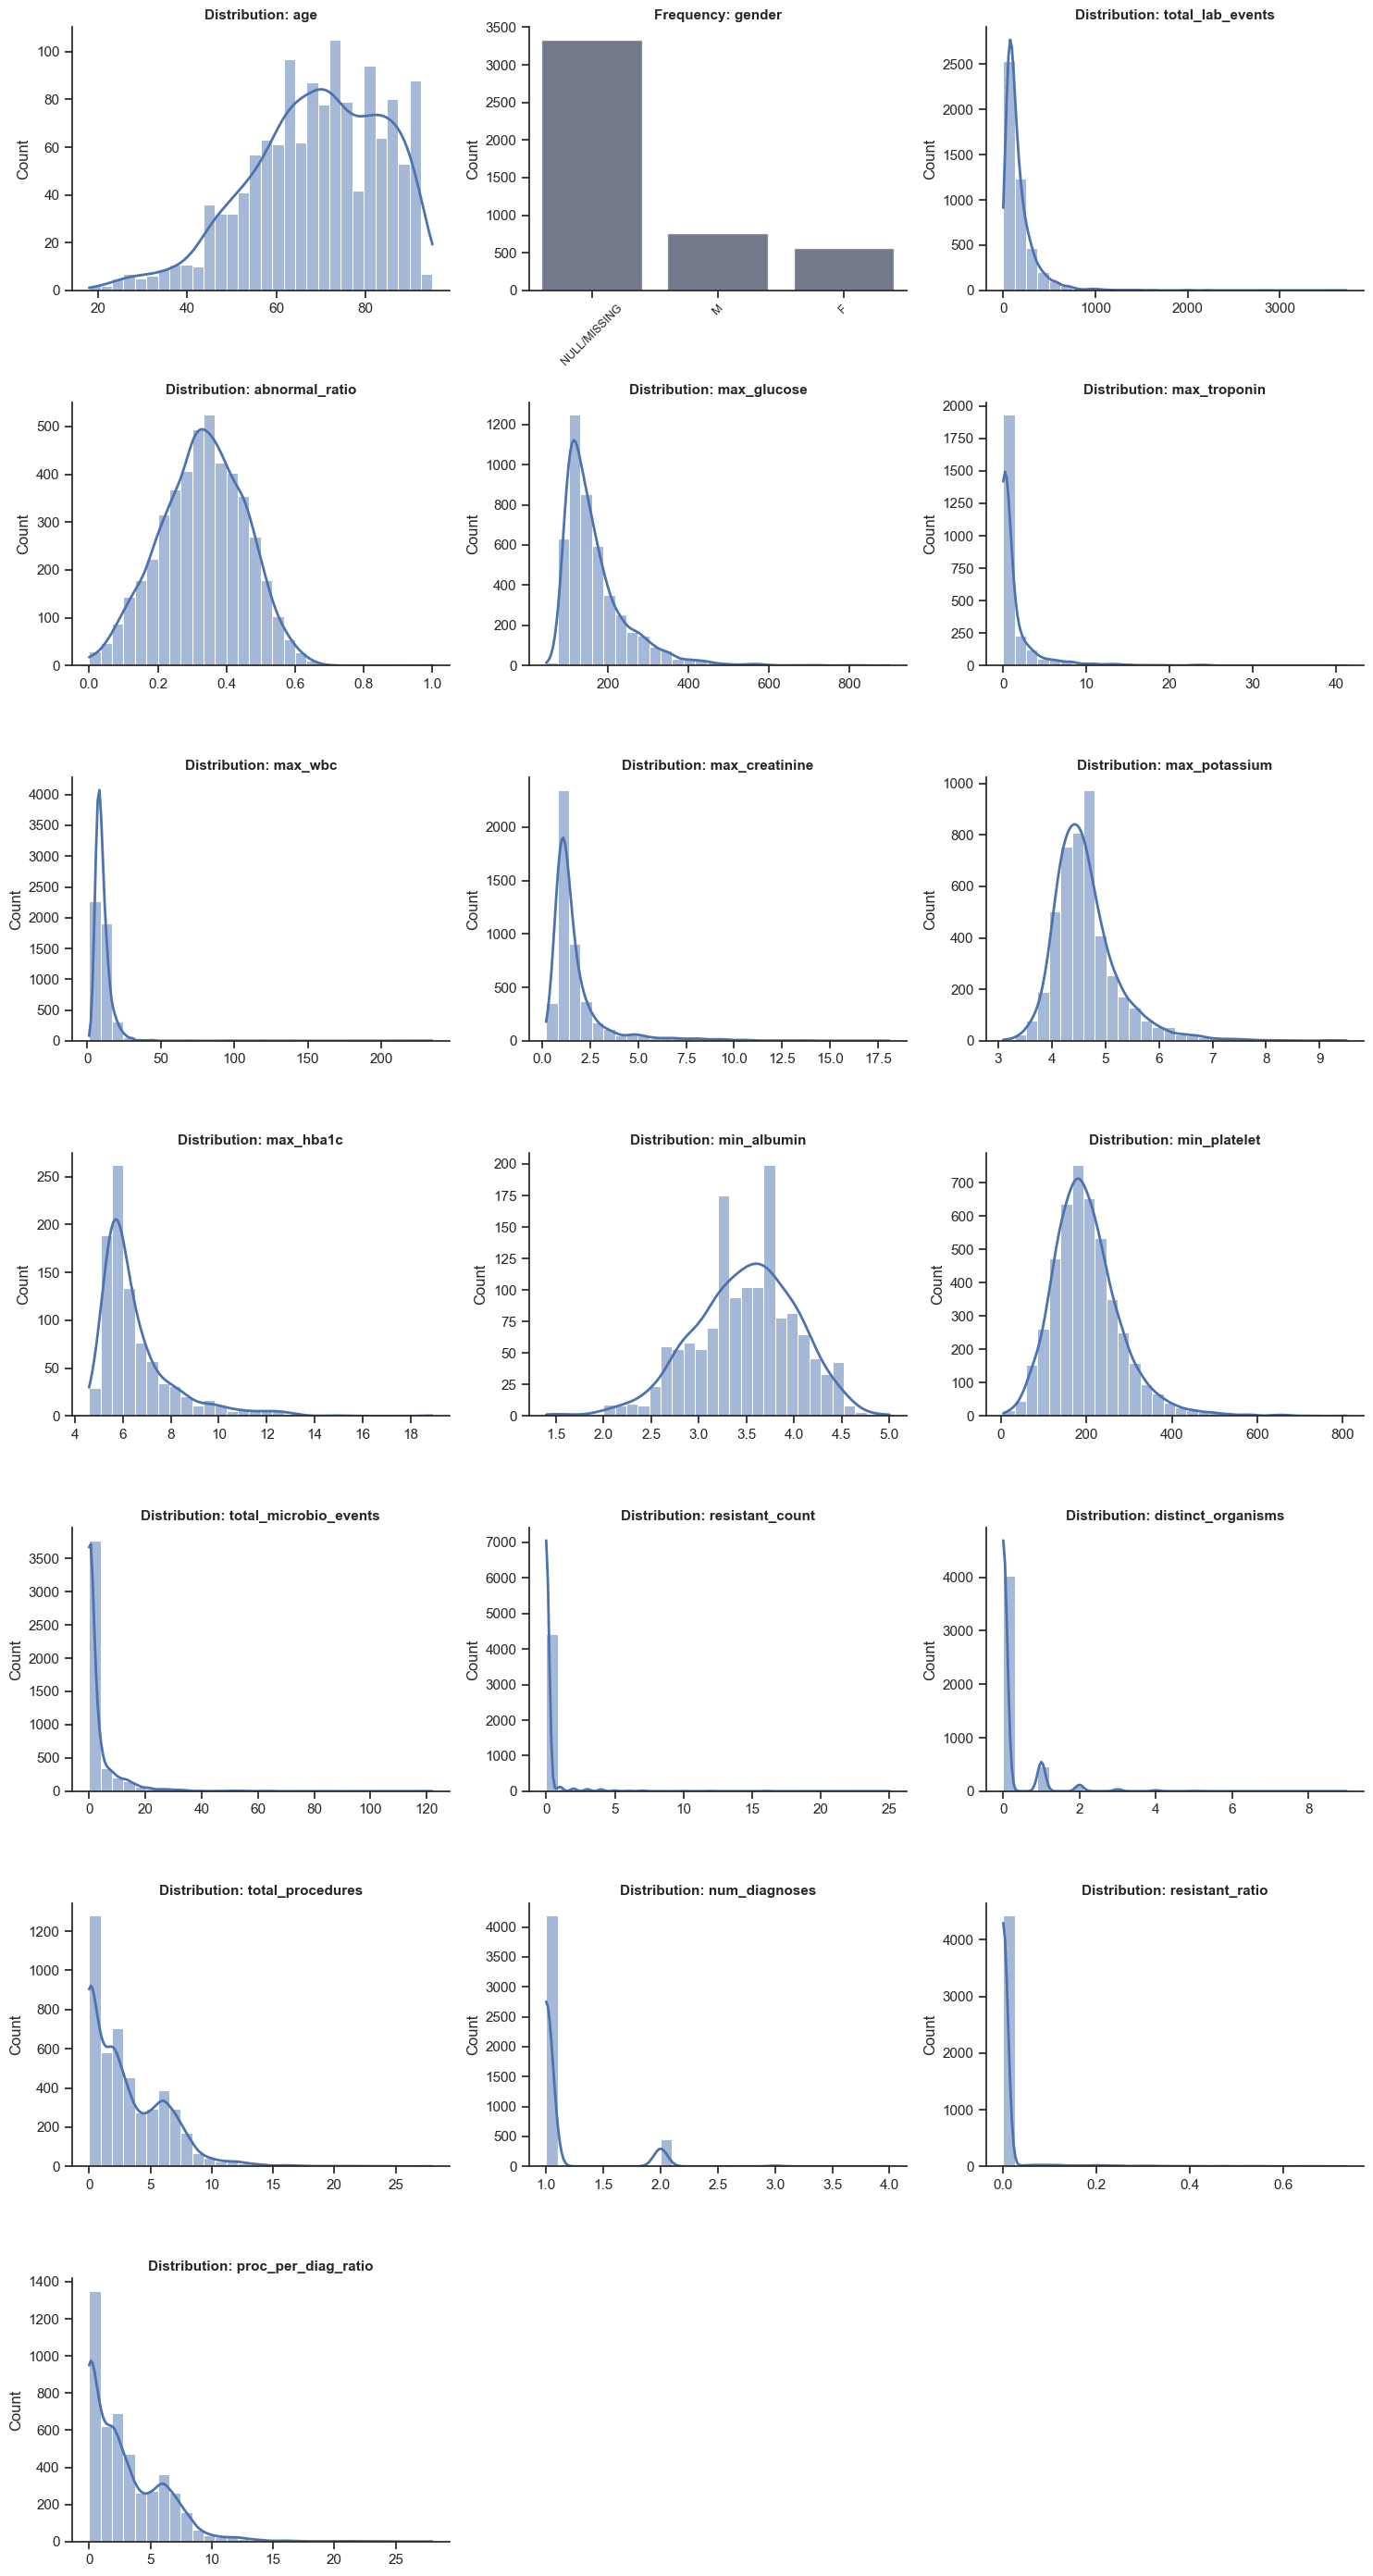

In [105]:
patient_df = pd.read_csv('../Data/patient_profile.csv')
patient_df.describe().to_csv('../Data/results/patient_describe.csv', index=True)
plot_patient_profile_panel_v2(patient_df, exclude_cols=['subject_id','hadm_id'])

# --- PART 3: Data Preprocessing---


To handle data quality issues effectively, we construct two separate patient profile views that are analyzed in parallel

### Core Data Quality Issue
Inspection of the dataset using `df.info()` reveals substantial missing demographic data:

- **Total rows:** 4,864  
- **`age` available:** 1,363  
- **`gender` available:** 1,363  

Approximately **72% of admissions lack age and gender information**, which directly impacts how the data can be used for clustering.

### Implications
Two straightforward approaches are unsuitable:

- Removing all rows with missing demographics would discard the majority of valid clinical data.
- Imputing demographic attributes would introduce artificial values and reduce analytical reliability.

## Two-View Analysis Strategy
To address this, we define two complementary dataset views.

### View 1: Demographic-Enriched Profile
- Includes only admissions with complete age and gender data.
- Enables analysis of demographic effects alongside clinical features.

### View 2: Clinical-Only Profile
- Includes all admissions but excludes age and gender.
- Enables clustering based solely on clinical and procedural information.





In [106]:
def trackMissingValues(df):
    null_df = df.isnull().sum().to_frame(name="null_count")
    null_df["% of total"] = round(null_df["null_count"] / len(df)*100, 2)
    return null_df

test = pd.read_csv("../Data/patient_profile.csv")
trackMissingValues(test).to_csv("../Data/results/missing_values_patient_profile.csv")

--- STARTING PRE-PROCESSING SCRIPT (Corrected) ---
Successfully loaded patient_profile.csv. Total rows: 4660
Converted Gender to numeric (M=1, F=0).
Imputing missing values for View 1...
Imputing missing values for View 2...

Generating boxplots...


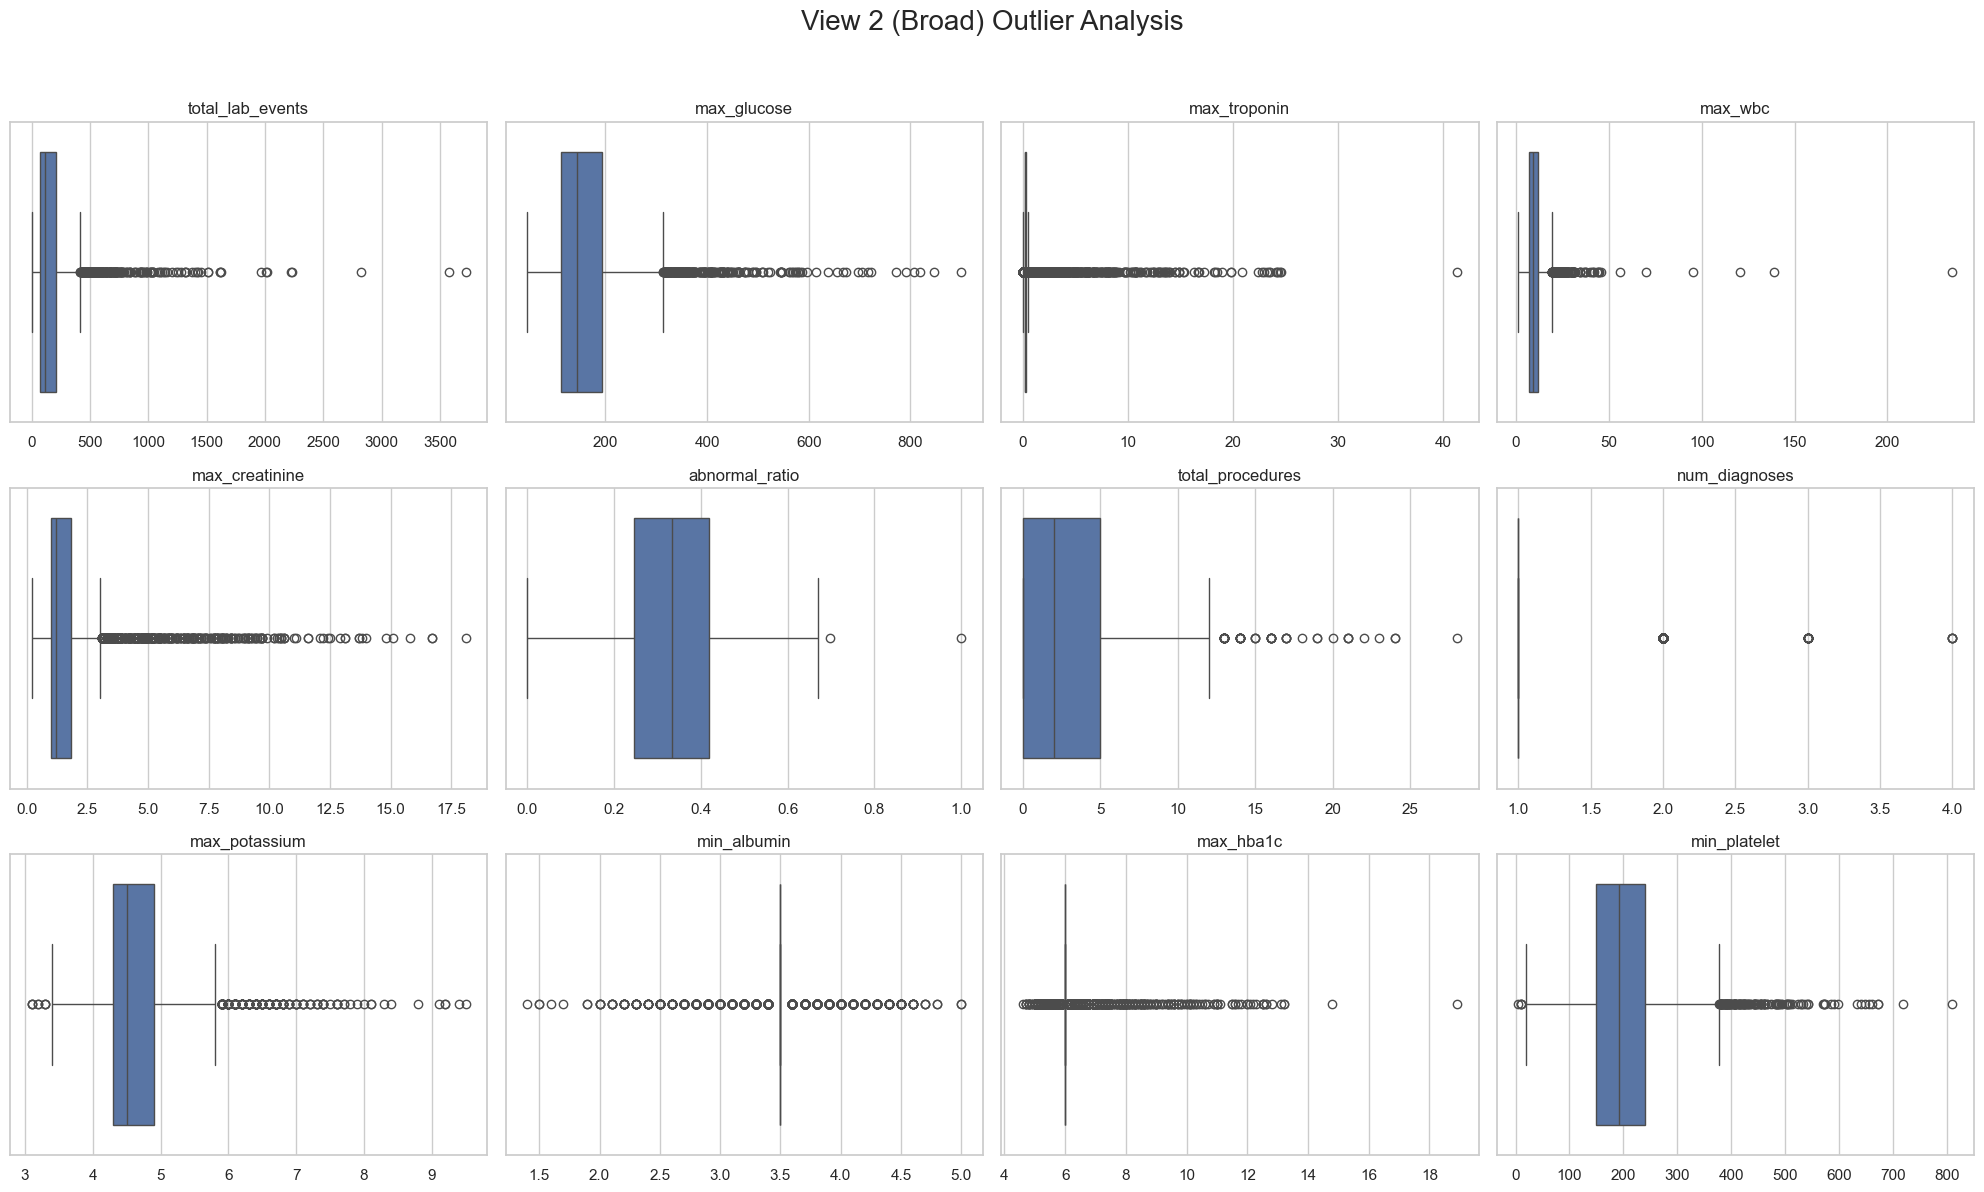

 SAVED CLEAN FILES:
1. ../Data/view1_deep_profile_cleaned.csv (Shape: (1326, 21))
2. ../Data/view2_broad_profile_cleaned.csv (Shape: (4660, 19))


In [107]:

sns.set(style="whitegrid")

print("--- STARTING PRE-PROCESSING SCRIPT (Corrected) ---")

path_in = "../Data/patient_profile.csv"
path_view1_out = "../Data/view1_deep_profile_cleaned.csv"
path_view2_out = "../Data/view2_broad_profile_cleaned.csv"

if not os.path.exists(path_in):
    print(f"ERROR: {path_in} not found. Run merge.ipynb first.")
    df_master = None
else:
    df_master = pd.read_csv(path_in)
    print(f"Successfully loaded patient_profile.csv. Total rows: {len(df_master)}")

if df_master is not None:
    # ---------------------------------------------------------
    # 1. FEATURE LISTS
    # ---------------------------------------------------------
    # Features to impute (fill missing with median)
    features_to_impute = [
        'max_glucose', 'max_troponin', 'max_wbc', 'max_creatinine', 
        'abnormal_ratio',
        # New features
        'max_potassium', 'min_albumin', 'max_hba1c', 'min_platelet'
    ]
    
    # Features to plot (for outlier check)
    features_to_plot = [
        'total_lab_events', 'max_glucose', 'max_troponin', 
        'max_wbc', 'max_creatinine', 'abnormal_ratio', 
        'total_procedures', 'num_diagnoses',
        'max_potassium', 'min_albumin', 'max_hba1c', 'min_platelet'
    ]

    # ---------------------------------------------------------
    # 2. VIEW 1: DEEP DEMOGRAPHIC PROFILE
    # ---------------------------------------------------------
    # Drop rows where age/gender are missing
    df_view1 = df_master.dropna(subset=['age', 'gender']).copy()
    
    df_view1['gender'] = df_view1['gender'].map({'M': 1, 'F': 0})
    print("Converted Gender to numeric (M=1, F=0).")
    
    # Impute missing clinical data
    print("Imputing missing values for View 1...")
    for col in features_to_impute:
        if col in df_view1.columns:
            median_val = df_view1[col].median()
            df_view1[col] = df_view1[col].fillna(median_val)

    # ---------------------------------------------------------
    # 3. VIEW 2: BROAD CLINICAL PROFILE
    # ---------------------------------------------------------
    # Drop age/gender columns entirely
    df_view2 = df_master.drop(columns=['age', 'gender']).copy()

    # Impute missing clinical data
    print("Imputing missing values for View 2...")
    for col in features_to_impute:
        if col in df_view2.columns:
            median_val = df_view2[col].median()
            df_view2[col] = df_view2[col].fillna(median_val)

    # ---------------------------------------------------------
    # 4. OUTLIER PLOTS
    # ---------------------------------------------------------
    print("\nGenerating boxplots...")
    plt.figure(figsize=(20, 15))
    plt.suptitle("View 2 (Broad) Outlier Analysis", fontsize=20, y=1.02)
    
    features_in_view2 = [col for col in features_to_plot if col in df_view2.columns]
    for i, col in enumerate(features_in_view2):
        plt.subplot(4, 4, i + 1)
        sns.boxplot(x=df_view2[col])
        plt.title(col)
        plt.xlabel(None)
    
    plt.tight_layout()
    plt.show()

   
    df_view1.to_csv(path_view1_out, index=False)
    df_view2.to_csv(path_view2_out, index=False)
    
    print(f" SAVED CLEAN FILES:")
    print(f"1. {path_view1_out} (Shape: {df_view1.shape})")
    print(f"2. {path_view2_out} (Shape: {df_view2.shape})")


Boxplot inspection shows that several continuous features are strongly skewed due to extreme values. To limit their influence, percentile-based clipping is applied only to highly skewed features. Count-based and ratio features are left unchanged to preserve their natural distributions.

Clipping at the 95th percentile is applied to:
- `total_lab_events`
- `max_glucose`
- `max_troponin`
- `max_wbc`
- `total_procedures`

### Step 3: Missing Value Imputation
Some clinical measurement features contain missing values. These are filled using median imputation..




In [108]:
import pandas as pd
import numpy as np
import os

print("--- STARTING PRE-PROCESSING SCRIPT (V5 - Final with New Features) ---")

# --- FINALIZED FEATURE LISTS ---

# 1. Features to CLIP 
features_to_clip = [
    'total_lab_events', 
    'max_glucose', 
    'max_troponin', 
    'max_wbc', 
    'total_procedures',
    'max_creatinine',
    'max_potassium',
    'max_hba1c',
    'min_platelet', 
    'min_albumin'
]

# 2. Features to IMPUTE 
features_to_impute = [
    'max_glucose', 
    'max_troponin', 
    'max_wbc', 
    'abnormal_ratio',
    'max_creatinine',
    'max_potassium', 
    'min_albumin', 
    'max_hba1c', 
    'min_platelet'
]

#3. Features to DELETE
# Low quality, not good imputable
features_to_delete = [
    "min_albumin",
    "max_hba1c"
]

# files
path_view1_in = "../Data/view1_deep_profile_cleaned.csv"
path_view2_in = "../Data/view2_broad_profile_cleaned.csv"
path_view1_out = "../Data/view1_clean_for_clustering.csv"
path_view2_out = "../Data/view2_clean_for_clustering.csv"
os.makedirs("../Data", exist_ok=True)

try:
    #load files
    df_view1 = pd.read_csv(path_view1_in)
    df_view2 = pd.read_csv(path_view2_in)
    print(f"Successfully loaded: {path_view1_in} (Shape: {df_view1.shape})")
    print(f"Successfully loaded: {path_view2_in} (Shape: {df_view2.shape})")

    # --- 1. PROCESS VIEW 1 (DEEP---
    print("\n--- Processing View 1: Deep Profile ---")
    
    
    #  Clip Outliers
    print(f"Clipping {len(features_to_clip)} features at 95th percentile...")
    for col in features_to_clip:
        if col in df_view1.columns:
            q_95 = df_view1[col].quantile(0.95)
            df_view1[col] = df_view1[col].clip(upper=q_95)
    
    # Impute Missing Values (Median)
    print(f"Imputing {len(features_to_impute)} features with median...")
    for col in features_to_impute:
        if col in df_view1.columns:
            median_val = df_view1[col].median()
            df_view1[col] = df_view1[col].fillna(median_val)
            
    # --- 2. PROCESS VIEW 2 Broad ---
    print("\n--- Processing View 2: Broad Profile ---")
    
    # Clip Outliers
    print(f"Clipping {len(features_to_clip)} features at 95th percentile...")
    for col in features_to_clip:
        if col in df_view2.columns:
            q_95 = df_view2[col].quantile(0.95)
            df_view2[col] = df_view2[col].clip(upper=q_95)
            
    # Impute Missing Values (Median)
    print(f"Imputing {len(features_to_impute)} features with median...")
    for col in features_to_impute:
        if col in df_view2.columns:
            median_val = df_view2[col].median()
            df_view2[col] = df_view2[col].fillna(median_val)
    
    # Delete low quality features
    print(f"Deleting {len(features_to_delete)} low-quality features...")
    for col in features_to_delete:
        if col in df_view1.columns:
            df_view1.drop(columns=[col], inplace=True)
            print(f"Deleted {col} from View 1")
        if col in df_view2.columns:
            df_view2.drop(columns=[col], inplace=True)
            print(f"Deleted {col} from View 2")
    # --- 3. SAVE AND VERIFY ---
    print("\n--- Saving Cleaned Files ---")
    df_view1.to_csv(path_view1_out, index=False)
    df_view2.to_csv(path_view2_out, index=False)
    print(f"Saved: {path_view1_out}")
    print(f"Saved: {path_view2_out}")
    
    print("\n--- VERIFICATION: VIEW 1 (CLEANED) ---")
    print(df_view1.info())
    print("\n--- VERIFICATION: VIEW 2 (CLEANED) ---")
    print(df_view2.info())
    
    print("\nFINISHED PRE PROCESSING")

except FileNotFoundError as e:
    print(f"\n--- ERROR ---")
    print(f"Could not find input file: {e.filename}")
    print("Please make sure you have run the Data Exploration step (to generate outlier files) first.")

--- STARTING PRE-PROCESSING SCRIPT (V5 - Final with New Features) ---
Successfully loaded: ../Data/view1_deep_profile_cleaned.csv (Shape: (1326, 21))
Successfully loaded: ../Data/view2_broad_profile_cleaned.csv (Shape: (4660, 19))

--- Processing View 1: Deep Profile ---
Clipping 10 features at 95th percentile...
Imputing 9 features with median...

--- Processing View 2: Broad Profile ---
Clipping 10 features at 95th percentile...
Imputing 9 features with median...
Deleting 2 low-quality features...
Deleted min_albumin from View 1
Deleted min_albumin from View 2
Deleted max_hba1c from View 1
Deleted max_hba1c from View 2

--- Saving Cleaned Files ---
Saved: ../Data/view1_clean_for_clustering.csv
Saved: ../Data/view2_clean_for_clustering.csv

--- VERIFICATION: VIEW 1 (CLEANED) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  ----- 

# Correlation Analysis

--- STARTING CORRELATION ANALYSIS (V2 - With New Features) ---
Successfully loaded: ../Data/view1_deep_profile_cleaned.csv
Successfully loaded: ../Data/view2_broad_profile_cleaned.csv

--- Generating Correlation Heatmap: View 1 (Deep Profile) ---


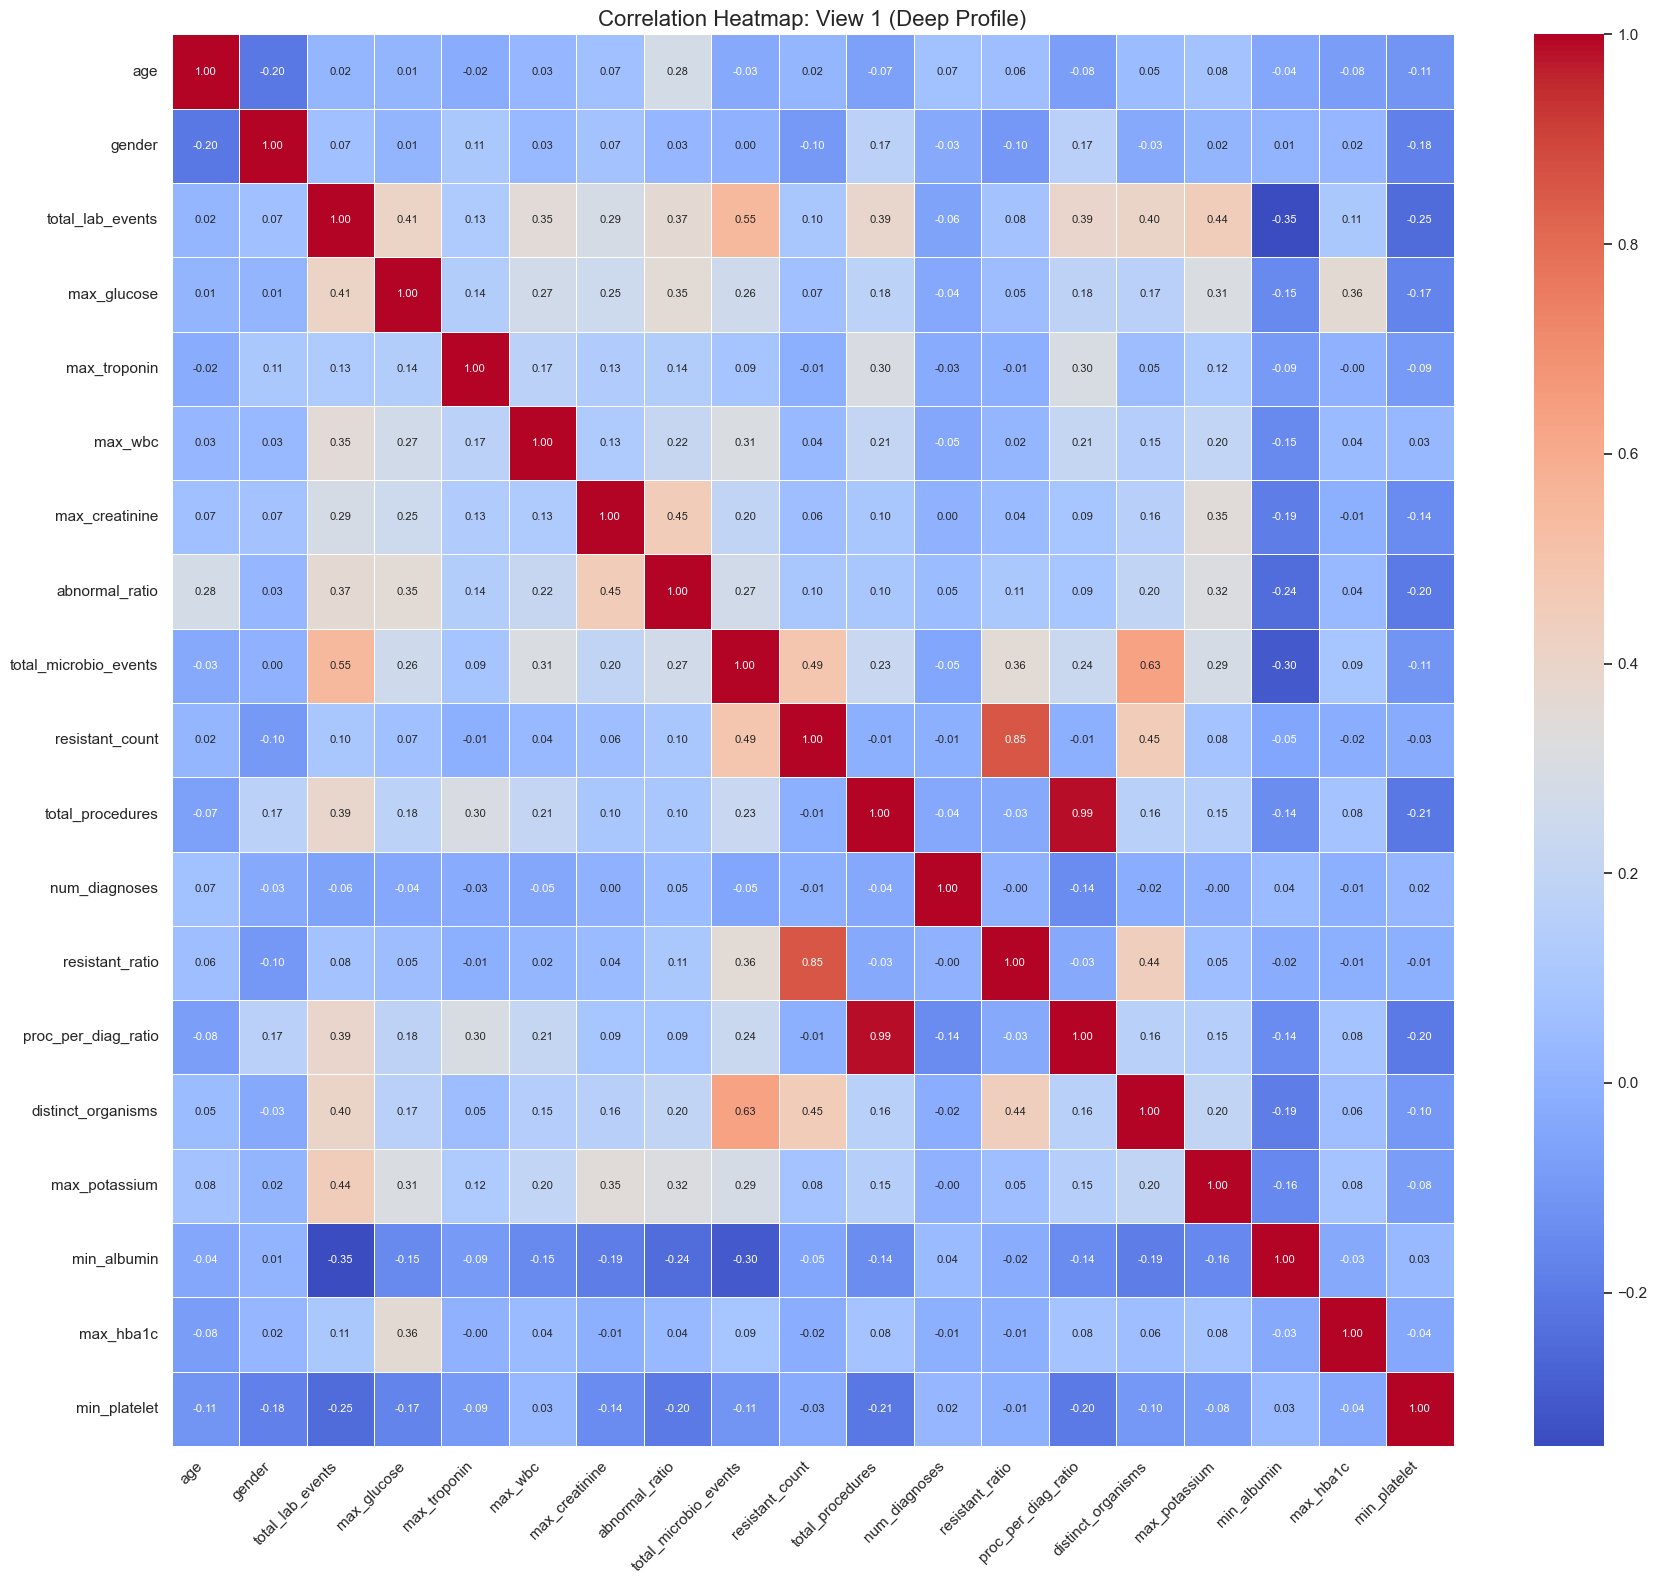


--- Generating Correlation Heatmap: View 2 (Broad Profile) ---


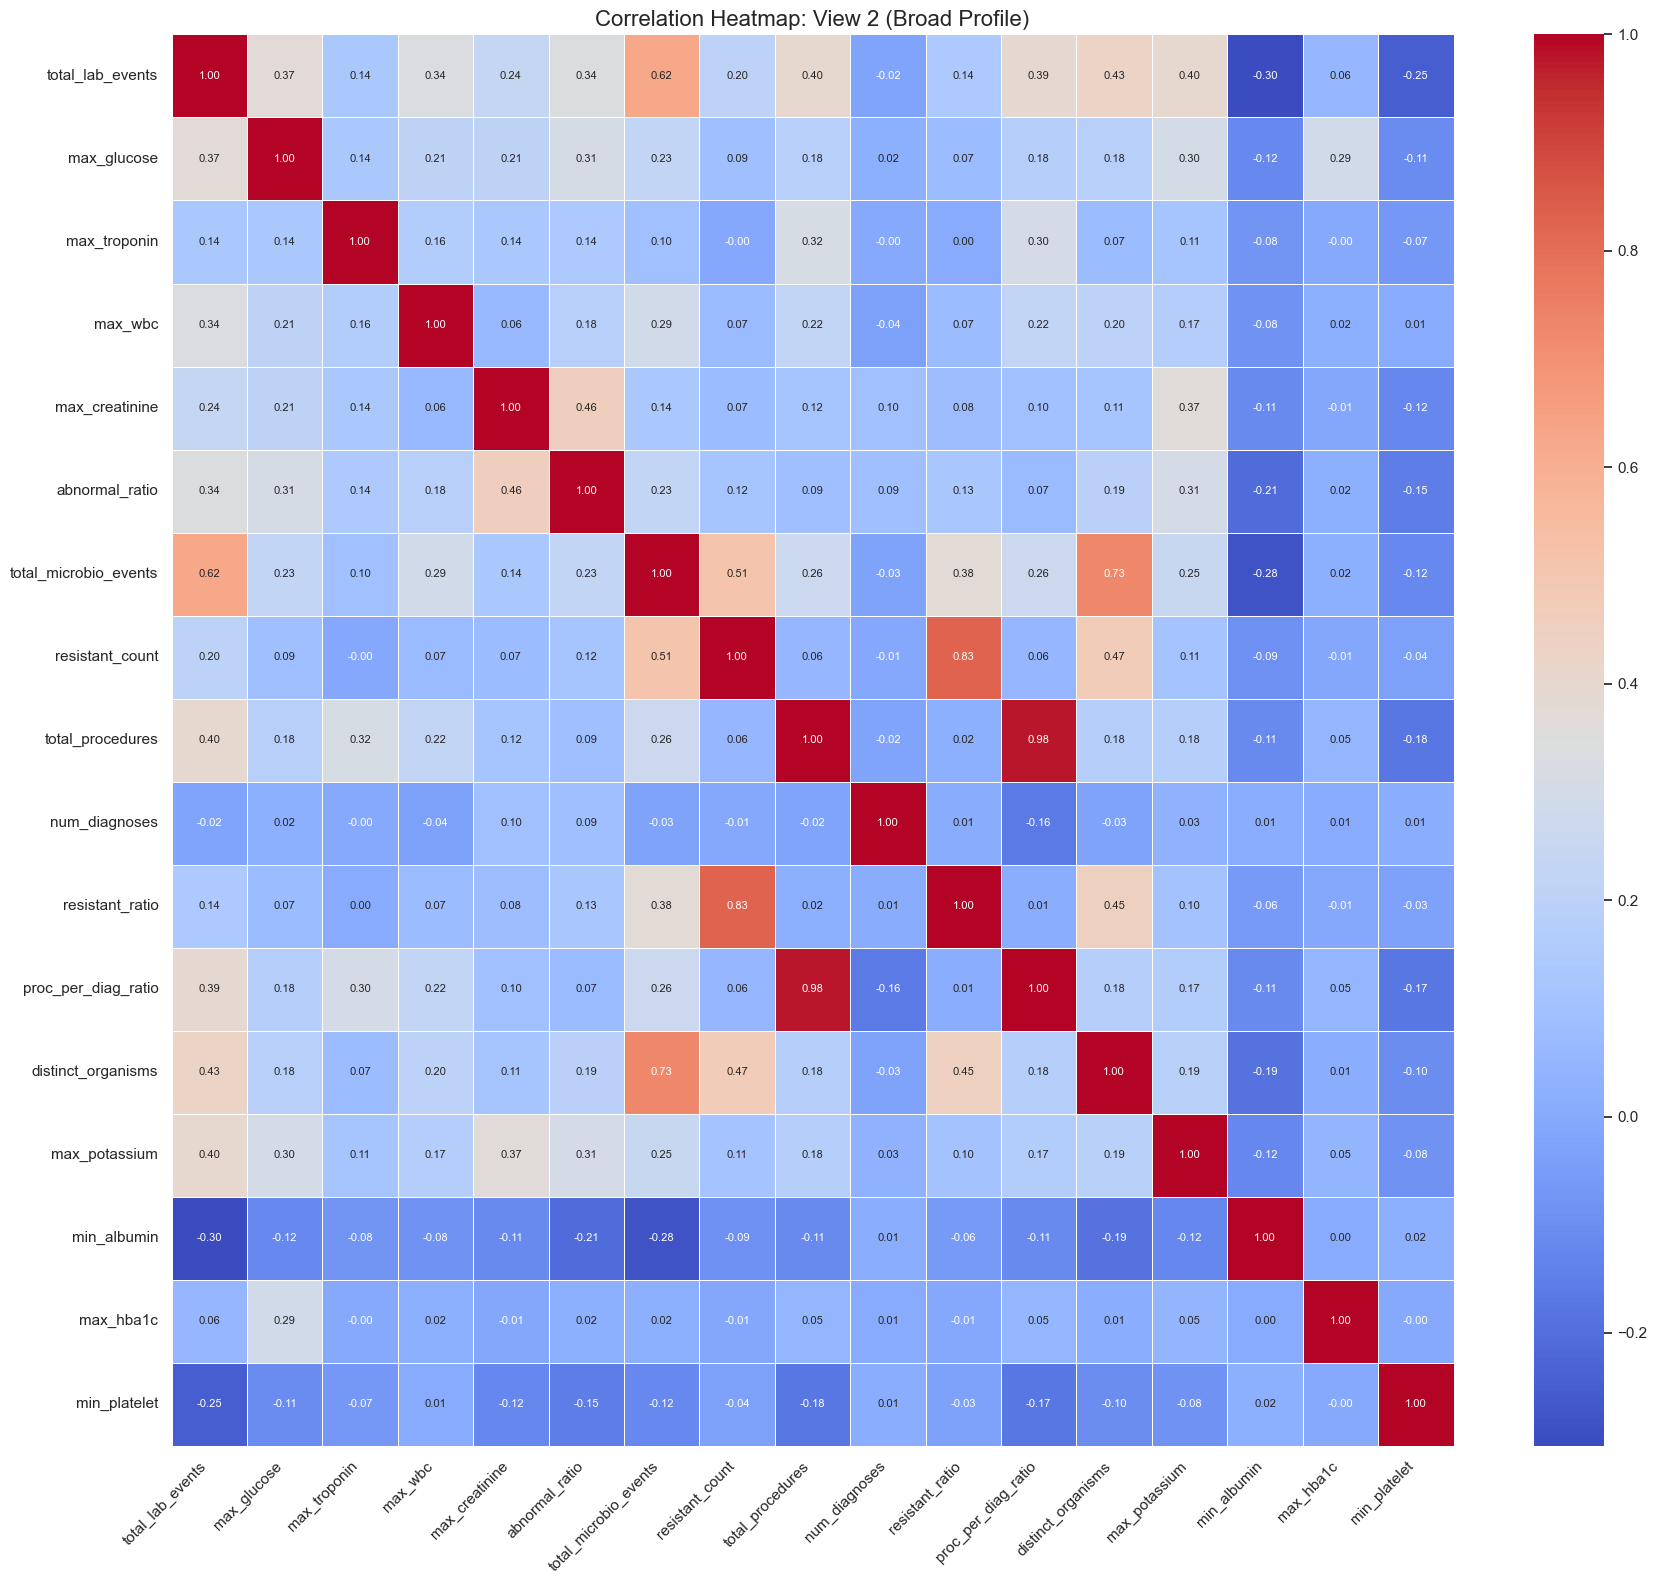


 Correlation analysis complete.


In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- STARTING CORRELATION ANALYSIS (V2 - With New Features) ---")

path_view1 = "../Data/view1_deep_profile_cleaned.csv"
path_view2 = "../Data/view2_broad_profile_cleaned.csv"

try:
    df_view1 = pd.read_csv(path_view1)
    df_view2 = pd.read_csv(path_view2)
    print(f"Successfully loaded: {path_view1}")
    print(f"Successfully loaded: {path_view2}")

    # --- 1. ANALYSIS FOR VIEW 1 (Deep Profile) ---
    print("\n--- Generating Correlation Heatmap: View 1 (Deep Profile) ---")
    
    
    features_view1 = [
        'age', 'gender', 
        'total_lab_events', 'max_glucose', 'max_troponin', 'max_wbc', 'max_creatinine',
        'abnormal_ratio', 'total_microbio_events', 
        'resistant_count', 'total_procedures', 'num_diagnoses', 
        'resistant_ratio', 'proc_per_diag_ratio','distinct_organisms',
        'max_potassium', 'min_albumin', 'max_hba1c', 'min_platelet'
    ]
    
    # Calculate the correlation matrix
    valid_features_v1 = [f for f in features_view1 if f in df_view1.columns]
    corr_matrix_v1 = df_view1[valid_features_v1].corr()
    
    plt.figure(figsize=(18, 16)) 
    sns.heatmap(
        corr_matrix_v1, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        linewidths=0.5,
        annot_kws={"size": 8} 
    )
    plt.title("Correlation Heatmap: View 1 (Deep Profile)", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --- 2. ANALYSIS FOR VIEW 2 (Broad Profile) ---
    print("\n--- Generating Correlation Heatmap: View 2 (Broad Profile) ---")
    
    # Define all features for View 2 including the NEW ones
    features_view2 = [
        'total_lab_events', 'max_glucose', 'max_troponin', 'max_wbc', 'max_creatinine',
        'abnormal_ratio', 'total_microbio_events', 'resistant_count', 
        'total_procedures', 'num_diagnoses', 'resistant_ratio', 
        'proc_per_diag_ratio','distinct_organisms',
        # --- NEW FEATURES ---
        'max_potassium', 'min_albumin', 'max_hba1c', 'min_platelet'
    ]
    
    valid_features_v2 = [f for f in features_view2 if f in df_view2.columns]
    corr_matrix_v2 = df_view2[valid_features_v2].corr()
    
    plt.figure(figsize=(18, 16))
    sns.heatmap(
        corr_matrix_v2, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        linewidths=0.5,
        annot_kws={"size": 8}
    )
    plt.title("Correlation Heatmap: View 2 (Broad Profile)", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("\n Correlation analysis complete.")

except FileNotFoundError as e:
    print(f"\n--- ERROR ---")
    print(f"Could not find input file: {e.filename}")
    print("Please make sure you have run 'pre_processing.ipynb' to generate the cleaned files.")

###  Analysis and Conclusions from the Heatmaps

The correlation heatmaps highlight both redundant features and meaningful clinical relationships.

Strong correlations show that `resistant_count` overlaps heavily with `total_microbio_events` and `resistant_ratio`, meaning it adds no new information beyond the normalized ratio. The feature `num_diagnoses` appears as a blank row and column, which confirms it has zero variance (constant value of 1) and carries no information. As a result, `proc_per_diag_ratio`, defined as `total_procedures / num_diagnoses`, is identical to `total_procedures` and is fully redundant.

At the same time, key clinical features such as `max_troponin` and `max_wbc` show weak correlation, indicating they capture independent clinical signals. Expected relationships are also present: `max_glucose` correlates strongly with `max_hba1c`, and `max_potassium` shows moderate correlation with `max_creatinine`. Features such as `min_albumin` and `min_platelet` remain largely independent, adding complementary information.


###  Feature Selection for Clustering

Based on the correlation analysis, the following features are removed:

- **Identifiers:** `subject_id`, `hadm_id`
- **Zero-variance:** `num_diagnoses`
- **Redundant:** `resistant_count`, `total_microbio_events`, `proc_per_diag_ratio`


### Final Feature Set

The final feature set used for clustering consists of 14:

1. `age`
2. `gender`
3. `total_lab_events`
4. `abnormal_ratio`
5. `max_glucose`
6. `max_troponin`
7. `resistant_ratio`
8. `total_procedures`
9. `distinct_organisms`
10. `max_creatinine`
11. `max_potassium`
12. `min_albumin`
13. `max_hba1c`
14. `min_platelet`
